# Vietnam Statistical Arbitrage: PCA + OU Mean Reversion
## Baseline Notebook (Long-Only + VN30 Futures Hedge)

This notebook implements a statistical arbitrage strategy for Vietnam stocks:
- **Factor Model**: Rolling PCA on stock returns
- **Signal**: OU/AR(1) mean-reversion fitted to residuals
- **Portfolio**: Long-only, equal-weight, VN30-hedged
- **Goal**: Validate the research pipeline before optimization

Pipeline:
1. Data loading & preprocessing
2. Universe definition
3. Rolling PCA factor extraction
4. Residual construction
5. OU/AR(1) mean-reversion fitting
6. S-score signal generation
7. Long-only signal logic
8. Equal-weight portfolio construction
9. VN30 futures hedge computation
10. Backtest engine
11. Performance analysis & diagnostics

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')
print(f'Pandas: {pd.__version__}')
print(f'NumPy: {np.__version__}')

Libraries loaded successfully.
Pandas: 2.3.3
NumPy: 2.4.3


# SECTION 1: Data Loading and Preprocessing
## Vietnam stocks + VN30 futures prices, volumes, and returns

In [53]:
## Define date range
START_DATE = '2018-01-02'
END_DATE   = '2025-12-31'

print(f'Analysis period: {START_DATE} to {END_DATE}\n')

## Load Vietnam stock prices
stock_price_df = pd.read_csv('vietnam_stock_price_full.csv', index_col=0, parse_dates=True)
print(f'Stock price shape: {stock_price_df.shape}')
print(f'Stock price date range: {stock_price_df.index.min().date()} to {stock_price_df.index.max().date()}')
print(f'Stock price missing (total): {stock_price_df.isna().sum().sum()}\n')

## Load Vietnam stock volumes
stock_volume_df = pd.read_csv('vietnam_stock_volume_full.csv', index_col=0, parse_dates=True)
print(f'Stock volume shape: {stock_volume_df.shape}')
print(f'Stock volume date range: {stock_volume_df.index.min().date()} to {stock_volume_df.index.max().date()}\n')

## Load VN30 futures prices
fu_vn30_df = pd.read_csv('FU_VN30_full.csv', index_col=0, parse_dates=True)
print(f'VN30 futures shape: {fu_vn30_df.shape}')
print(f'VN30 futures date range: {fu_vn30_df.index.min().date()} to {fu_vn30_df.index.max().date()}\n')

Analysis period: 2018-01-02 to 2025-12-31

Stock price shape: (2872, 702)
Stock price date range: 2014-07-09 to 2025-12-31
Stock price missing (total): 248600

Stock volume shape: (2872, 702)
Stock volume date range: 2014-07-09 to 2025-12-31

VN30 futures shape: (2141, 5)
VN30 futures date range: 2017-08-10 to 2026-03-11



In [54]:
# =========================
# FIX 2: clean stock data without creating fake tradability
# =========================
missing_pct = stock_price_df.isna().mean() * 100
stocks_to_keep = missing_pct[missing_pct <= 5].index

print(f"Removing {len(stock_price_df.columns) - len(stocks_to_keep)} stocks with >5% missing data")
print(f"Keeping {len(stocks_to_keep)} stocks initially")

stock_price_clean = stock_price_df[stocks_to_keep].copy()
stock_volume_clean = stock_volume_df[stocks_to_keep].copy()

# Do NOT forward-fill prices or volume for trading logic

valid_ratio = stock_price_clean.notna().mean()
stocks_final = valid_ratio[valid_ratio >= 0.95].index

stock_price_clean = stock_price_clean[stocks_final].copy()
stock_volume_clean = stock_volume_clean[stocks_final].copy()

print(f"After secondary filter: {len(stocks_final)} stocks")
print(f"Price shape: {stock_price_clean.shape}")
print(f"Volume shape: {stock_volume_clean.shape}")

# =========================
# FIX 1: choose VN30 futures close explicitly
# =========================
if isinstance(fu_vn30_df, pd.DataFrame):
    lower_map = {str(c).lower(): c for c in fu_vn30_df.columns}

    if 'close' in lower_map:
        vn30_price_aligned = fu_vn30_df[lower_map['close']].copy()
    elif 'settlement price' in lower_map:
        vn30_price_aligned = fu_vn30_df[lower_map['settlement price']].copy()
    else:
        raise ValueError(
            f"Cannot identify futures close column. Available columns: {list(fu_vn30_df.columns)}"
        )
else:
    vn30_price_aligned = fu_vn30_df.copy()

vn30_price_aligned.name = 'VN30_FUT_CLOSE'
print("Using VN30 futures series:", vn30_price_aligned.name)

# =========================
# FIX 3: align dates and build tradability mask
# =========================
common_dates = (
    stock_price_clean.index
    .intersection(stock_volume_clean.index)
    .intersection(vn30_price_aligned.index)
)

stock_price = stock_price_clean.loc[common_dates].copy()
stock_volume = stock_volume_clean.loc[common_dates].copy()
vn30_price = vn30_price_aligned.loc[common_dates].copy()

tradable_mask = (
    stock_price.notna() &
    stock_volume.notna() &
    (stock_volume > 0)
)

print("Aligned stock price shape:", stock_price.shape)
print("Aligned stock volume shape:", stock_volume.shape)
print("Aligned VN30 futures shape:", vn30_price.shape)
print("Tradable entries:", tradable_mask.sum().sum())

Removing 276 stocks with >5% missing data
Keeping 426 stocks initially
After secondary filter: 426 stocks
Price shape: (2872, 426)
Volume shape: (2872, 426)
Using VN30 futures series: VN30_FUT_CLOSE
Aligned stock price shape: (2098, 426)
Aligned stock volume shape: (2098, 426)
Aligned VN30 futures shape: (2098,)
Tradable entries: 769288


In [55]:
# =========================
# FIX 5: compute returns only where both days are tradable
# =========================
stock_returns_raw = stock_price.pct_change()
vn30_returns = vn30_price.pct_change()

tradable_return_mask = tradable_mask & tradable_mask.shift(1)

stock_returns = stock_returns_raw.where(tradable_return_mask)
stock_returns = stock_returns.dropna(how='all')

vn30_returns = vn30_returns.dropna()

common_dates = stock_returns.index.intersection(vn30_returns.index)

stock_returns = stock_returns.loc[common_dates]
vn30_returns = vn30_returns.loc[common_dates]
stock_price = stock_price.loc[common_dates]
stock_volume = stock_volume.loc[common_dates]
tradable_mask = tradable_mask.loc[common_dates]

print("Stock returns shape:", stock_returns.shape)
print("VN30 returns shape:", vn30_returns.shape)

## Summary statistics
print('Stock returns summary:')
print(f'  Mean: {stock_returns.mean().mean():.6f}')
print(f'  Std:  {stock_returns.std().mean():.6f}')
print(f'  Min:  {stock_returns.min().min():.6f}')
print(f'  Max:  {stock_returns.max().max():.6f}\n')

print('VN30 returns summary:')
print(f'  Mean: {vn30_returns.mean():.6f}')
print(f'  Std:  {vn30_returns.std():.6f}')
print(f'  Min:  {vn30_returns.min():.6f}')
print(f'  Max:  {vn30_returns.max():.6f}')

Stock returns shape: (2097, 426)
VN30 returns shape: (2097,)
Stock returns summary:
  Mean: inf
  Std:  0.031406
  Min:  -1.000000
  Max:  inf

VN30 returns summary:
  Mean: 0.000589
  Std:  0.014873
  Min:  -0.110069
  Max:  0.069971


# SECTION 2: Universe Definition
## Define trading universe based on liquidity filters
Universe logic: select top N stocks by average volume over a rolling window

In [56]:
def select_liquid_universe(price_df, volume_df, date, top_n=300, lookback_window=366):
    """
    Select top N stocks by liquidity on a given date.
    
    Args:
        price_df: DataFrame of stock prices
        volume_df: DataFrame of stock volumes
        date: Trading date
        top_n: Number of top liquid stocks to select
        lookback_window: Days to look back for liquidity calculation
        
    Returns:
        price_window: Clean price data for selected stocks
        volume_window: Clean volume data for selected stocks
    """
    # Filter stocks with price data available on the given date
    stocks_available = price_df.loc[date].notna()
    
    # Get lookback window
    window_start = date - pd.Timedelta(days=lookback_window)
    price_window = price_df.loc[window_start:date, stocks_available].copy()
    volume_window = volume_df.loc[window_start:date, stocks_available].copy()
    
    # Calculate average volume (most recent day)
    latest_volume = volume_window.iloc[-1]  # Most recent volume
    top_stocks = latest_volume.nlargest(top_n).index.tolist()
    
    # Clean: forward-fill, drop rows with any missing in final selection
    price_window = price_window[top_stocks].ffill(limit=2)
    price_window = price_window.dropna(axis=1, how='any')
    
    final_stocks = price_window.columns
    volume_window = volume_window[final_stocks].ffill(limit=5)
    
    return price_window, volume_window

## Test universe selection on a recent date
test_date = stock_price.index[-100]  # 100 days before end
test_price, test_volume = select_liquid_universe(stock_price, stock_volume, test_date, top_n=100)
print(f'Universe selection test (date={test_date.date()}):')
print(f'  Selected {len(test_price.columns)} liquid stocks')
print(f'  Price data shape: {test_price.shape}')
print(f'  Volume data shape: {test_volume.shape}')

Universe selection test (date=2025-08-12):
  Selected 100 liquid stocks
  Price data shape: (250, 100)
  Volume data shape: (250, 100)


# SECTION 3: Rolling PCA Factor Extraction
## Compute PCA factors on rolling estimation window
Strategy: standardize returns, compute empirical correlation, perform eigendecomposition

In [57]:
def standardize_returns(ret_window):
    """
    Standardize returns: Y_ik = (R_ik - mean_i) / std_i per stock
    """
    mean_per_stock = ret_window.mean(axis=0)
    std_per_stock = ret_window.std(axis=0, ddof=1).replace(0, np.nan)
    Y = (ret_window - mean_per_stock) / std_per_stock
    return Y.dropna(axis=1)  # drop any stock with zero std

def compute_correlation_matrix(Y):
    """
    Compute empirical correlation from standardized returns
    """
    M = Y.shape[0]  # number of observations
    return (Y.values.T @ Y.values) / (M - 1)

def eigen_decomposition_sorted(corr_matrix):
    """
    Eigendecomposition with eigenvalues sorted descending
    """
    eigvals, eigvecs = np.linalg.eigh(corr_matrix)
    idx = np.argsort(eigvals)[::-1]
    return eigvals[idx], eigvecs[:, idx]

# =========================
# FIX 6: robust rolling PCA
# =========================
def rolling_pca(returns, estimation_window=252, n_factors=5, min_stocks=20):
    dates = returns.index
    pca_dict = {}

    for t in range(estimation_window, len(dates)):
        trading_date = dates[t]

        est_start = t - estimation_window
        est_end = t
        ret_window = returns.iloc[est_start:est_end].copy()

        ret_window = ret_window.dropna(axis=1, how='any')
        if ret_window.shape[1] < min_stocks:
            continue

        mean_per_stock = ret_window.mean(axis=0)
        std_per_stock = ret_window.std(axis=0, ddof=1)

        valid_cols = std_per_stock[std_per_stock > 1e-12].index
        ret_window = ret_window[valid_cols]
        mean_per_stock = mean_per_stock[valid_cols]
        std_per_stock = std_per_stock[valid_cols]

        if ret_window.shape[1] < min_stocks:
            continue

        Y = (ret_window - mean_per_stock) / std_per_stock
        corr = np.corrcoef(Y.values.T)

        eigvals, eigvecs = np.linalg.eigh(corr)
        idx = np.argsort(eigvals)[::-1]
        eigvals = eigvals[idx]
        eigvecs = eigvecs[:, idx]

        k = min(n_factors, ret_window.shape[1] - 1)
        if k < 1:
            continue

        V = eigvecs[:, :k]
        Q = V / std_per_stock.values.reshape(-1, 1)

        pca_dict[trading_date] = {
            'Q': Q,
            'stocks': ret_window.columns.tolist(),
            'k': k,
            'eigvals': eigvals[:k],
        }

    return pca_dict

## Run rolling PCA
print("Running rolling PCA...")
pca_results = rolling_pca(stock_returns, estimation_window=252, n_factors=5, min_stocks=20)
print(f"PCA available for {len(pca_results)} dates")

Running rolling PCA...
PCA available for 1845 dates


# SECTION 4: Residual Construction
## Use PCA factors to compute fitted & residual returns

In [58]:
# =========================
# FIX 7: correct residual regression
# =========================
def compute_residuals(returns, pca_dict, regression_window=60, min_obs=40):
    dates = returns.index
    residuals = pd.DataFrame(index=dates, columns=returns.columns, dtype=float)

    for trading_date in sorted(pca_dict.keys()):
        if trading_date not in dates:
            continue

        t = dates.get_loc(trading_date)
        if t < regression_window:
            continue

        pca_info = pca_dict[trading_date]
        Q = pca_info['Q']
        stocks = pca_info['stocks']

        reg_start = t - regression_window
        reg_end = t
        R_reg_df = returns.iloc[reg_start:reg_end][stocks].copy()

        valid_rows = R_reg_df.notna().all(axis=1)
        R_reg_df = R_reg_df.loc[valid_rows]

        if R_reg_df.shape[0] < min_obs:
            continue

        R_reg = R_reg_df.values
        F_reg = R_reg @ Q

        X = np.column_stack([np.ones(R_reg.shape[0]), F_reg])

        r_today = returns.loc[trading_date, stocks]
        if r_today.isna().any():
            continue

        r_today = r_today.values
        f_today = r_today @ Q
        x_today = np.concatenate([[1.0], f_today])

        try:
            beta_all = np.linalg.lstsq(X, R_reg, rcond=None)[0]
        except np.linalg.LinAlgError:
            continue

        fitted_ret = x_today @ beta_all

        for i, stock in enumerate(stocks):
            residuals.loc[trading_date, stock] = r_today[i] - fitted_ret[i]

    return residuals

print("Computing residuals...")
residuals = compute_residuals(stock_returns, pca_results, regression_window=60, min_obs=40)
print("Residuals shape:", residuals.shape)
print("Residual missing:", residuals.isna().sum().sum())

Computing residuals...
Residuals shape: (2097, 426)
Residual missing: 574819


# SECTION 5: OU/AR(1) Mean Reversion Fitting
## Fit Ornstein-Uhlenbeck model to residuals to estimate mean-reversion parameters

In [59]:
# =========================
# FIX 8: robust OU fitting
# =========================
def fit_ou_model(
    residuals,
    window=60,
    limit=False,
    kappa_min=8.4,
    min_obs=40,
    return_details=True
 ):
    kappa = pd.DataFrame(index=residuals.index, columns=residuals.columns, dtype=float)
    mu = kappa.copy()
    sigma_eq = kappa.copy()

    for col in residuals.columns:
        series = residuals[col]

        for t in range(window, len(series)):
            eps_win = series.iloc[t - window:t].dropna()

            if len(eps_win) < min_obs:
                continue

            Xcum = eps_win.cumsum().values
            if len(Xcum) < 3:
                continue

            x_prev = Xcum[:-1]
            x_next = Xcum[1:]

            A = np.column_stack([np.ones(len(x_prev)), x_prev])

            try:
                a, b = np.linalg.lstsq(A, x_next, rcond=None)[0]
            except np.linalg.LinAlgError:
                continue

            resid_ar = x_next - (a + b * x_prev)
            var_xi = np.var(resid_ar, ddof=1)

            if not np.isfinite(b) or not np.isfinite(var_xi):
                continue
            if var_xi <= 1e-12:
                continue
            if b <= 0 or b >= 0.9672:
                continue

            kappa_val = -np.log(b) * 252.0
            mu_val = a / (1.0 - b)
            sigma_eq_val = np.sqrt(var_xi / (1.0 - b**2))

            if not np.isfinite(kappa_val) or not np.isfinite(mu_val) or not np.isfinite(sigma_eq_val):
                continue
            if sigma_eq_val <= 1e-12:
                continue
            if limit and kappa_val < kappa_min:
                continue

            date = series.index[t]
            kappa.loc[date, col] = kappa_val
            mu.loc[date, col] = mu_val
            sigma_eq.loc[date, col] = sigma_eq_val

    # Combined daily dataframe: rows=days, columns=(Stock, Stat)
    # Example columns: ('AAA', 'kappa'), ('AAA', 'mu'), ('AAA', 'sigma_eq')
    ou_daily_df = pd.concat({'kappa': kappa, 'mu': mu, 'sigma_eq': sigma_eq}, axis=1)
    ou_daily_df = ou_daily_df.swaplevel(0, 1, axis=1).sort_index(axis=1, level=0)
    ou_daily_df.columns.names = ['Stock', 'Stat']

    if return_details:
        return ou_daily_df, kappa, mu, sigma_eq
    return ou_daily_df

## Fit OU model (without kappa filter first)
print('Fitting OU model to residuals (limit=False)...')
ou_daily_df, kappa_df, mu_df, sigma_eq_df = fit_ou_model(
    residuals=residuals,
    window=60,
    limit=False,
    kappa_min=8.4,
    return_details=True
 )
print('OU parameters created')
print(f'OU daily shape (days x stock-stat): {ou_daily_df.shape}')
print(f'Unique stocks: {ou_daily_df.columns.get_level_values("Stock").nunique()}')
print(f'Stats per stock: {ou_daily_df.columns.get_level_values("Stat").unique().tolist()}')
print(f'Kappa median: {kappa_df.stack().median():.2f} (annualized)')
print(f'Sigma_eq median: {sigma_eq_df.stack().median():.6f}')
ou_daily_df.head()

Fitting OU model to residuals (limit=False)...
OU parameters created
OU daily shape (days x stock-stat): (2097, 1278)
Unique stocks: 426
Stats per stock: ['kappa', 'mu', 'sigma_eq']
Kappa median: 30.01 (annualized)
Sigma_eq median: 0.038602


Stock        AAA                AAM                ABT                ACB  \
Stat       kappa  mu sigma_eq kappa  mu sigma_eq kappa  mu sigma_eq kappa   
2017-08-11   NaN NaN      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN   
2017-08-14   NaN NaN      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN   
2017-08-15   NaN NaN      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN   
2017-08-16   NaN NaN      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN   
2017-08-17   NaN NaN      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN   

Stock       ...      VTO   VTV                WCS                WSS      \
Stat        ... sigma_eq kappa  mu sigma_eq kappa  mu sigma_eq kappa  mu   
2017-08-11  ...      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN NaN   
2017-08-14  ...      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN NaN   
2017-08-15  ...      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN NaN   
2017-08-16  ...      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN NaN   
2017-08-17  ...      NaN   NaN NaN      NaN   NaN NaN      NaN   NaN NaN   

Stock                
Stat       sigma_eq  
2017-08-11      NaN  
2017-08-14      NaN  
2017-08-15      NaN  
2017-08-16      NaN  
2017-08-17      NaN  

[5 rows x 1278 columns]

In [60]:
## Create focused OU parameter summary dataframe
print('\nCreating focused OU parameter summary...')

ou_stats_list = []
kappa_min = 8.4  # From paper's filtering logic

for stock in kappa_df.columns:
    kappa_vals = kappa_df[stock].dropna()
    mu_vals = mu_df[stock].dropna()
    sigma_eq_vals = sigma_eq_df[stock].dropna()
    
    if len(kappa_vals) == 0:
        continue
    
    # Calculate derived metrics
    kappa_median = kappa_vals.median()
    kappa_q1 = kappa_vals.quantile(0.25)
    kappa_q3 = kappa_vals.quantile(0.75)
    kappa_iqr = kappa_q3 - kappa_q1
    
    # Half-life in days (ln(2) / kappa, where kappa is annualized)
    halflife_median = np.log(2) / kappa_median if kappa_median > 0 else np.nan
    
    # Pass rate: percentage of kappa values >= kappa_min threshold
    pass_rate_kappa = (kappa_vals >= kappa_min).sum() / len(kappa_vals) * 100
    
    row = {
        'Stock': stock,
        'Valid_OU_Fits': len(kappa_vals),
        'Kappa_Median': kappa_median,
        'Kappa_IQR': kappa_iqr,
        'HalfLife_Median': halflife_median,
        'PassRate_Kappa': pass_rate_kappa,
        'SigmaEq_Median': sigma_eq_vals.median(),
        'AbsMu_Median': abs(mu_vals.median()),
    }
    ou_stats_list.append(row)

ou_stats_df = pd.DataFrame(ou_stats_list).set_index('Stock')
ou_stats_df


Creating focused OU parameter summary...


,Valid_OU_Fits,Kappa_Median,Kappa_IQR,HalfLife_Median,PassRate_Kappa,SigmaEq_Median,AbsMu_Median
Stock,,,,,,,
WSS,87,27.112591,23.192624,0.025566,100.0,0.047238,0.068561
VTV,377,51.790575,62.072611,0.013384,100.0,0.034905,0.024229
VTO,1263,32.417026,28.643402,0.021382,100.0,0.034363,0.002513
VSH,1004,31.350824,31.787647,0.022109,100.0,0.024687,0.008915
VSC,1307,23.738733,21.157637,0.029199,100.0,0.043590,0.010856
...,...,...,...,...,...,...,...
ACL,1375,33.186058,32.298972,0.020887,100.0,0.039935,0.013783
ACC,796,28.055858,29.678667,0.024706,100.0,0.030578,0.018905
ACB,1376,29.637581,29.391344,0.023387,100.0,0.020747,0.007390


### Định nghĩa các cột dữ liệu (Column Definitions)
- Valid_OU_Fits (Độ bao phủ khớp lệnh): 

Số lượng các lần khớp tham số OU hợp lệ cho mỗi mã cổ phiếu (thể hiện tính đầy đủ của dữ liệu).
- Kappa_Median (Tốc độ hồi quy trung vị): 

Giá trị trung vị của tốc độ hồi quy về mức trung bình (mean-reversion speed) đã được quy năm.
- Kappa_IQR (Độ ổn định tham số): 

Khoảng cách giữa các tứ phân vị (Q3 - Q1), dùng để đo lường độ ổn định của tham số Kappa.
- HalfLife_Median (Thời gian bán rã trung vị): 

Thời gian trung vị tính bằng ngày để mức thặng dư giảm đi một nửa, tính theo công thức: ln(2) / Kappa\_Median.
- PassRate_Kappa (Tỷ lệ vượt ngưỡng Kappa): 

Tỷ lệ phần trăm (%) các quan sát có Kappa $\geq$ 8.4 (phù hợp với logic lọc tín hiệu của bài báo gốc).
- SigmaEq_Median (Biến động cân bằng trung vị): 

Giá trị trung vị của độ biến động tại trạng thái cân bằng (hỗ trợ việc chuẩn hóa/thang đo tín hiệu).
- AbsMu_Median (Độ lệch cân bằng tuyệt đối trung vị): 

Giá trị trung vị của trị tuyệt đối độ lệch trạng thái cân bằng (dùng để tránh việc triệt tiêu dấu khi tính toán độ lệch tổng thể).


# SECTION 6: S-Score Signal Generation
## Compute standardized signal from residuals and OU parameters

In [61]:
# =========================
# FIX 9: stable s-score computation
# =========================
def compute_s_score(residuals, mu, sigma_eq, window=60, min_obs=40):
    sscore_df = pd.DataFrame(index=residuals.index, columns=residuals.columns, dtype=float)

    for col in residuals.columns:
        eps = residuals[col]

        for t in range(window, len(eps)):
            eps_win = eps.iloc[t - window:t].dropna()
            if len(eps_win) < min_obs:
                continue

            x_t = eps_win.cumsum().iloc[-1]
            mu_t = mu.iloc[t, mu.columns.get_loc(col)]
            sigma_t = sigma_eq.iloc[t, sigma_eq.columns.get_loc(col)]

            if pd.isna(mu_t) or pd.isna(sigma_t) or sigma_t <= 1e-12:
                continue

            sscore_df.iloc[t, sscore_df.columns.get_loc(col)] = (x_t - mu_t) / sigma_t

    return sscore_df

## Compute s-scores
print('Computing s-scores...')
sscore_df = compute_s_score(residuals, mu_df, sigma_eq_df, window=60)
print(f'S-score shape: {sscore_df.shape}')
print(f'S-score median: {sscore_df.stack().median():.4f}')
print(f'S-score std: {sscore_df.stack().std():.4f}')

Computing s-scores...
S-score shape: (2097, 426)
S-score median: -0.0560
S-score std: 0.9386


# SECTION 7: Long-Only Signal Logic
## Generate long-only trading signals based on s-score thresholds

Trading rules (long-only baseline):
- Open long: when s-score falls below -threshold (stock oversold/undervalued)
- Close long: when s-score rises above -close_threshold (mean-reversion towards equilibrium)

In [62]:
def compute_dynamic_entry_cutoff_cross_sectional(
    s_df,
    entry_pct=5,
    ma_window=60,
    min_valid_stocks=5,
    min_valid_days=None
):
    """
    A1 Dynamic Cutoff: Cross-sectional quantile + rolling MA smoothing.
    
    Steps:
    1. Each day t: compute entry_pct percentile from left tail of s-scores
    2. Smooth with rolling 60-day average
    """
    if min_valid_days is None:
        min_valid_days = max(10, ma_window // 2)

    def row_quantile(row):
        valid = row.dropna()
        if len(valid) < min_valid_stocks:
            return np.nan
        return valid.quantile(entry_pct / 100.0)

    raw_cutoff = s_df.apply(row_quantile, axis=1)
    entry_cutoff = raw_cutoff.rolling(
        window=ma_window,
        min_periods=min_valid_days
    ).mean()

    return raw_cutoff, entry_cutoff


def compute_fixed_entry_cutoff(
    s_df,
    entry_cutoff_value=-1.5
):
    """
    A2 Fixed Cutoff: Constant threshold for all dates.
    """
    entry_cutoff = pd.Series(
        entry_cutoff_value,
        index=s_df.index,
        dtype=float,
        name="fixed_entry_cutoff"
    )
    return entry_cutoff


def generate_long_only_signals_from_cutoff(
    s_df,
    entry_cutoff_series,
    tradable_mask=None,
    close_cutoff=-0.5
):
    """
    Generate long-only signals:
    - Open long: s[t-1] < entry_cutoff[t-1]
    - Close long: s[t-1] > close_cutoff (fixed for all setups)
    """
    signals = pd.DataFrame(0, index=s_df.index, columns=s_df.columns, dtype=int)
    current = pd.Series(0, index=s_df.columns, dtype=int)

    for t in range(1, len(s_df.index)):
        date = s_df.index[t]
        prev_date = s_df.index[t - 1]

        s_prev = s_df.loc[prev_date]
        entry_cutoff_prev = entry_cutoff_series.loc[prev_date]

        if tradable_mask is not None:
            tradable_today = tradable_mask.loc[date].reindex(s_df.columns).fillna(False)
        else:
            tradable_today = pd.Series(True, index=s_df.columns)

        cutoff_available = pd.notna(entry_cutoff_prev)

        for stock in s_df.columns:
            val = s_prev[stock]

            if pd.isna(val) or (not tradable_today[stock]):
                current[stock] = 0
                continue

            if current[stock] == 0:
                if cutoff_available and (val < entry_cutoff_prev):
                    current[stock] = 1
            else:
                if val > close_cutoff:
                    current[stock] = 0

        signals.loc[date] = current.values

    return signals


def prepare_entry_cutoff(
    s_df,
    method="A1",
    entry_pct=5,
    ma_window=60,
    fixed_entry_cutoff=-1.5,
    min_valid_stocks=5,
    min_valid_days=None
):
    """
    Wrapper dispatcher for A1 (dynamic) vs A2 (fixed) cutoff methods.
    """
    method = method.upper()

    if method == "A1":
        raw_cutoff, entry_cutoff = compute_dynamic_entry_cutoff_cross_sectional(
            s_df=s_df,
            entry_pct=entry_pct,
            ma_window=ma_window,
            min_valid_stocks=min_valid_stocks,
            min_valid_days=min_valid_days
        )
        return entry_cutoff, raw_cutoff

    elif method == "A2":
        entry_cutoff = compute_fixed_entry_cutoff(
            s_df=s_df,
            entry_cutoff_value=fixed_entry_cutoff
        )
        return entry_cutoff, None

    else:
        raise ValueError("method must be 'A1' or 'A2'")

print('✓ Cutoff functions defined (A1 dynamic, A2 fixed)')

✓ Cutoff functions defined (A1 dynamic, A2 fixed)


In [63]:
## Apply A1 (dynamic) cutoff
entry_cutoff_A1, raw_cutoff_A1 = prepare_entry_cutoff(
    s_df=sscore_df,
    method="A1",
    entry_pct=5,
    ma_window=60
)

signals_A1 = generate_long_only_signals_from_cutoff(
    s_df=sscore_df,
    entry_cutoff_series=entry_cutoff_A1,
    tradable_mask=tradable_mask,
    close_cutoff=-0.5
)

print('A1 signals generated (dynamic cutoff)')

## Apply A2 (fixed) cutoff
entry_cutoff_A2, _ = prepare_entry_cutoff(
    s_df=sscore_df,
    method="A2",
    fixed_entry_cutoff=-1.5
)

signals_A2 = generate_long_only_signals_from_cutoff(
    s_df=sscore_df,
    entry_cutoff_series=entry_cutoff_A2,
    tradable_mask=tradable_mask,
    close_cutoff=-0.5
)

print('A2 signals generated (fixed cutoff = -1.5)')

# Use A1 as default for further analysis
signals_df = signals_A1

A1 signals generated (dynamic cutoff)
A2 signals generated (fixed cutoff = -1.5)


# SECTION 8: Equal-Weight Portfolio Construction
## Build equal-weight long-only portfolio from signals

Portfolio rules:
- Equal weight across all active long positions on each date
- No leverage, no optimization
- Simple and transparent construction

In [64]:
# =========================
# PORTFOLIO WEIGHTING MODULE (MODULAR, 4 METHODS)
# =========================
# Easy-to-swap weighting functions for long-only contrarian stat-arb strategy
# Each method returns normalized weights (sum=1) across active stocks

def weight_equal(s_scores, active_mask):
    """
    METHOD 1: EQUAL WEIGHT
    Every active stock gets identical weight.
    
    Parameters
    ----------
    s_scores : pd.Series
        S-scores (not used in this method)
    active_mask : pd.Series
        Boolean Series, True = active long position
    Returns
    -------
    pd.Series
        Normalized weights, inactive stocks = 0
    """
    raw = pd.Series(1.0, index=active_mask.index)
    raw[~active_mask] = 0.0
    total = raw.sum()
    if total < 1e-12:
        return pd.Series(0.0, index=active_mask.index)
    return raw / total


def weight_linear_distance(s_scores, active_mask, q_open):
    """
    METHOD 2: LINEAR DISTANCE WEIGHTING
    Weight proportional to signal distance beyond opening threshold.
    
    Distance formula (for contrarian strategy):
        d_i = max(0, q_open - s_i)
    
    where:
    - q_open is the opening threshold (typically left-tail quantile, e.g., 5th percentile)
    - s_i is the s-score (more negative = stronger signal)
    - This measures "how far into the long territory" the stock is
    
    Parameters
    ----------
    s_scores : pd.Series
        Standardized s-scores by ticker
    active_mask : pd.Series
        Boolean Series, True = active long position
    q_open : float
        Opening threshold (e.g., 5th percentile or -1.56)
    
    Returns
    -------
    pd.Series
        Normalized weights, inactive stocks = 0
    
    Examples
    --------
    q_open = -1.56
    s = pd.Series({'A': -1.30, 'B': -1.60, 'C': -2.10})
    active = pd.Series({'A': True, 'B': True, 'C': True})
    
    Distance: d_A = 0.00, d_B = 0.04, d_C = 0.54
    Weights after normalization: 0, 0.069, 0.931
    """
    if q_open is None:
        raise ValueError("weight_linear_distance requires q_open parameter")
    
    # Compute distance: d_i = max(0, q_open - s_i)
    distance = np.maximum(0.0, q_open - s_scores)
    
    # Apply active mask: inactive stocks get zero
    raw = distance.copy()
    raw[~active_mask] = 0.0
    
    # Normalize
    total = raw.sum()
    if total < 1e-12:
        return pd.Series(0.0, index=active_mask.index)
    return raw / total


def weight_capped_linear_distance(s_scores, active_mask, q_open, signal_cap=0.75):
    """
    METHOD 3: CAPPED LINEAR DISTANCE WEIGHTING
    Linear distance weighting with a cap to reduce extreme concentration.
    
    Distance: d_i = max(0, q_open - s_i)
    Raw score: a_i = min(d_i, signal_cap) for active, 0 for inactive
    
    Purpose: preserve signal ordering while limiting excessive concentration from outliers
    
    Parameters
    ----------
    s_scores : pd.Series
        Standardized s-scores by ticker
    active_mask : pd.Series
        Boolean Series, True = active long position
    q_open : float
        Opening threshold
    signal_cap : float, default 0.75
        Maximum raw score before normalization
    
    Returns
    -------
    pd.Series
        Normalized weights, inactive stocks = 0
    """
    if q_open is None:
        raise ValueError("weight_capped_linear_distance requires q_open parameter")
    
    # Compute distance
    distance = np.maximum(0.0, q_open - s_scores)
    
    # Cap the distance
    capped = np.minimum(distance, signal_cap)
    
    # Apply active mask
    raw = capped.copy()
    raw[~active_mask] = 0.0
    
    # Normalize
    total = raw.sum()
    if total < 1e-12:
        return pd.Series(0.0, index=active_mask.index)
    return raw / total


def weight_ou_expected_return(s_scores, active_mask, q_open, kappa, sigma_eq=None):
    """
    METHOD 4: OU-BASED EXPECTED RETURN WEIGHTING
    Weight by distance scaled by OU mean-reversion quality.
    
    Core formula:
        d_i = max(0, q_open - s_i)
        a_i = kappa_i * d_i
    
    Optional variant (if sigma_eq provided):
        a_i = kappa_i * d_i / sigma_eq_i
    
    Intuition: stocks with higher mean-reversion speed (kappa) should get more weight
    for the same signal strength. Higher kappa = faster reversion to mean.
    
    Parameters
    ----------
    s_scores : pd.Series
        Standardized s-scores by ticker
    active_mask : pd.Series
        Boolean Series, True = active long position
    q_open : float
        Opening threshold
    kappa : pd.Series
        OU mean-reversion speed by ticker (>0 preferred)
        If missing or nonpositive, that ticker gets zero weight
    sigma_eq : pd.Series, optional
        Equilibrium volatility by ticker
        If provided, divides the raw score (risk adjustment)
    
    Returns
    -------
    pd.Series
        Normalized weights, inactive stocks = 0
    """
    if q_open is None:
        raise ValueError("weight_ou_expected_return requires q_open parameter")
    if kappa is None:
        raise ValueError("weight_ou_expected_return requires kappa parameter")
    
    # Ensure kappa is aligned to s_scores index
    kappa = kappa.reindex(s_scores.index).fillna(0.0)
    
    # Compute distance
    distance = np.maximum(0.0, q_open - s_scores)
    
    # Scale by kappa: filter out nonpositive kappa (no mean reversion)
    scaled_distance = distance.copy()
    scaled_distance[kappa <= 0.0] = 0.0  # No weight if kappa invalid
    scaled_distance[kappa > 0.0] = scaled_distance[kappa > 0.0] * kappa[kappa > 0.0]
    
    # Optional volatility adjustment
    if sigma_eq is not None:
        sigma_eq = sigma_eq.reindex(s_scores.index).fillna(1e-6)
        sigma_eq = np.maximum(sigma_eq, 1e-6)  # Prevent division by zero
        scaled_distance = scaled_distance / sigma_eq
    
    # Apply active mask
    raw = scaled_distance.copy()
    raw[~active_mask] = 0.0
    
    # Normalize
    total = raw.sum()
    if total < 1e-12:
        return pd.Series(0.0, index=active_mask.index)
    return raw / total


def apply_weight_cap(weights, max_weight):
    """
    HELPER: Apply per-stock weight cap with proportional redistribution.
    
    Caps each weight at max_weight, then redistributes excess to uncapped positions.
    Repeat until feasible or max iterations reached.
    
    Parameters
    ----------
    weights : pd.Series
        Portfolio weights (should sum to ~1.0)
    max_weight : float or None
        Maximum weight per position. If None or >= 1.0, returns unchanged.
    
    Returns
    -------
    pd.Series
        Capped weights (normalized to sum = 1.0 if possible)
    """
    if max_weight is None or max_weight >= 1.0:
        return weights
    
    w = weights.copy()
    max_iters = 10
    
    for _ in range(max_iters):
        # Cap all weights
        excess = (w - max_weight).clip(lower=0.0).sum()
        w = w.clip(upper=max_weight)
        
        if excess < 1e-12:
            break
        
        # Redistribute to uncapped
        uncapped_mask = w < max_weight - 1e-12
        uncapped_sum = w[uncapped_mask].sum()
        
        if uncapped_sum < 1e-12:
            break  # No room to redistribute
        
        redistribution = excess * (w[uncapped_mask] + 1e-12) / (uncapped_sum + 1e-12)
        w[uncapped_mask] += redistribution
    
    # Final normalization
    total = w.sum()
    if total < 1e-12:
        return pd.Series(0.0, index=weights.index)
    return w / total


def compute_portfolio_weights(
    s_scores,
    active_mask,
    method="equal",
    q_open=None,
    signal_cap=0.75,
    kappa=None,
    sigma_eq=None,
    max_weight=None
):
    """
    WRAPPER: Main dispatcher for portfolio weighting methods.
    
    Selects one of 4 weighting methods and returns normalized weights.
    
    Parameters
    ----------
    s_scores : pd.Series
        S-scores indexed by ticker
    active_mask : pd.Series
        Boolean mask (True = active long position)
    method : str, default "equal"
        Method choice: "equal", "linear", "capped_linear", "ou"
    q_open : float, optional
        Signal threshold (required for linear, capped_linear, ou methods)
    signal_cap : float, default 0.75
        Cap for capped_linear method
    kappa : pd.Series, optional
        OU mean-reversion speed (required for ou method)
    sigma_eq : pd.Series, optional
        Equilibrium volatility (optional for ou method)
    max_weight : float, optional
        Final per-stock weight cap
    
    Returns
    -------
    pd.Series
        Normalized weights (sum=1), indexed by ticker
    
    Raises
    ------
    ValueError
        If method is unknown or required parameters are missing
    
    Examples
    --------
    # Toy data
    s_scores = pd.Series([-1.5, -0.8, -2.1], index=['A', 'B', 'C'])
    active = pd.Series([True, True, True], index=['A', 'B', 'C'])
    
    # Equal weight
    w1 = compute_portfolio_weights(s_scores, active, method="equal")
    # Result: A=0.333, B=0.333, C=0.333
    
    # Linear distance (q_open = -1.56)
    w2 = compute_portfolio_weights(s_scores, active, method="linear", q_open=-1.56)
    # Result depends on distances beyond q_open
    
    # OU-based
    kappa = pd.Series([0.15, 0.10, 0.20], index=['A', 'B', 'C'])
    w3 = compute_portfolio_weights(s_scores, active, method="ou", q_open=-1.56, kappa=kappa)
    """
    # Align all inputs to same index
    common_idx = s_scores.index.union(active_mask.index)
    s_scores = s_scores.reindex(common_idx).fillna(0.0)
    active_mask = active_mask.reindex(common_idx).fillna(False)
    
    # Dispatch to chosen method
    if method == "equal":
        weights = weight_equal(s_scores, active_mask)
    elif method == "linear":
        weights = weight_linear_distance(s_scores, active_mask, q_open)
    elif method == "capped_linear":
        weights = weight_capped_linear_distance(s_scores, active_mask, q_open, signal_cap)
    elif method == "ou":
        weights = weight_ou_expected_return(s_scores, active_mask, q_open, kappa, sigma_eq)
    else:
        raise ValueError(f"Unknown method: {method}. Choose from: equal, linear, capped_linear, ou")
    
    # Apply optional final weight cap
    if max_weight is not None:
        weights = apply_weight_cap(weights, max_weight)
    
    return weights


# SECTION 9: VN30 Futures Hedge Computation
## Compute rolling beta and hedge VN30 systematic risk with short futures

In [65]:
# =========================
# FIX 12: rolling beta without look-ahead
# =========================
def compute_rolling_beta(stock_portfolio_returns, vn30_returns, beta_window=60):
    common_idx = stock_portfolio_returns.index.intersection(vn30_returns.index)
    R_stock = stock_portfolio_returns.loc[common_idx]
    R_vn30 = vn30_returns.loc[common_idx]

    beta_series = pd.Series(np.nan, index=common_idx)

    for t in range(beta_window, len(common_idx)):
        date = common_idx[t]

        stock_window = R_stock.iloc[t - beta_window:t]
        vn30_window = R_vn30.iloc[t - beta_window:t]

        valid = stock_window.notna() & vn30_window.notna()
        stock_window = stock_window[valid]
        vn30_window = vn30_window[valid]

        if len(stock_window) < max(20, beta_window // 2):
            continue

        var_vn30 = np.var(vn30_window, ddof=1)
        if var_vn30 <= 1e-12:
            beta_series.loc[date] = 0.0
            continue

        cov = np.cov(stock_window, vn30_window)[0, 1]
        beta_series.loc[date] = cov / var_vn30

    return beta_series

## Ensure weights_df exists and is aligned before hedge computation
if 'weights_df' not in globals():
    if 'w_equal' in globals():
        print('weights_df not found. Using w_equal from Section 8 as default.')
        weights_df = w_equal.copy()
    else:
        print('weights_df not found. Building equal-weight portfolio from signals_df.')
        weights_df = signals_df.astype(float)
        weight_sum = weights_df.sum(axis=1).replace(0, np.nan)
        weights_df = weights_df.div(weight_sum, axis=0).fillna(0.0)

weights_df = (
    weights_df
    .reindex(index=stock_returns.index, columns=stock_returns.columns, fill_value=0.0)
    .fillna(0.0)
)

## Compute portfolio returns and beta
print('Computing rolling beta for hedge sizing...')

# Portfolio stock returns (when long)
portfolio_returns = (weights_df * stock_returns).sum(axis=1)

# Rolling beta
beta_series = compute_rolling_beta(portfolio_returns, vn30_returns, beta_window=60)

print(f'weights_df shape: {weights_df.shape}')
print(f'Portfolio returns shape: {portfolio_returns.shape}')
print(f'Beta series shape: {beta_series.shape}')
print(f'Mean beta: {beta_series.mean():.4f}')
print(f'Median beta: {beta_series.median():.4f}')
print(f'Std beta: {beta_series.std():.4f}')

Computing rolling beta for hedge sizing...
weights_df shape: (2097, 426)
Portfolio returns shape: (2097,)
Beta series shape: (2097,)
Mean beta: 0.5870
Median beta: 0.5999
Std beta: 0.3170


# SECTION 10: Backtest Engine
## Single clean backtest for PCA + long-only portfolio + VN30 hedge

In [66]:
def backtest_strategy(weights_df, stock_returns, vn30_returns, beta_series, 
                      initial_equity=100, slippage=0.0005):
    """
    Backtest long-only stock portfolio + VN30 futures hedge.
    
    Daily equity update:
    - Stock leg: position weights * stock returns
    - Hedge leg: -beta * vn30 returns (short futures)
    - Slippage: on position changes
    
    Args:
        weights_df: Portfolio weights
        stock_returns: Stock returns
        vn30_returns: VN30 futures returns
        beta_series: Rolling beta
        initial_equity: Starting equity
        slippage: Transaction cost factor
        
    Returns:
        equity_curve: Series of daily equity values
    """
    # Align data
    common_idx = (weights_df.index
                  .intersection(stock_returns.index)
                  .intersection(vn30_returns.index)
                  .intersection(beta_series.index))
    
    w = weights_df.loc[common_idx].fillna(0)
    r_stock = stock_returns.loc[common_idx].fillna(0)
    r_vn30 = vn30_returns.loc[common_idx].fillna(0)
    beta = beta_series.loc[common_idx].fillna(0)
    
    # Initialize equity curve with explicit float dtype
    equity = pd.Series(initial_equity, index=common_idx, dtype=float)
    
    for t in range(1, len(common_idx)):
        date_t = common_idx[t]
        date_prev = common_idx[t - 1]
        
        E_prev = equity.iloc[t - 1]
        
        # Current equity and positions
        w_today = w.loc[date_t]
        beta_today = beta.loc[date_t]
        r_stock_today = r_stock.loc[date_t]
        r_vn30_today = r_vn30.loc[date_t]
        
        # Stock leg position (in dollars)
        Q_stock = E_prev * w_today
        
        # VN30 futures hedge (short, sized by beta)
        Q_vn30 = -E_prev * beta_today
        
        # PnL
        pnl_stock = (Q_stock * r_stock_today).sum()
        pnl_vn30 = Q_vn30 * r_vn30_today
        
        # Transaction costs (only on position changes)
        if t > 1:
            w_prev = w.loc[date_prev]
            beta_prev = beta.loc[date_prev]
            Q_stock_prev = equity.iloc[t - 2] * w_prev
            Q_vn30_prev = -equity.iloc[t - 2] * beta_prev
        else:
            Q_stock_prev = pd.Series(0, index=w.columns)
            Q_vn30_prev = 0
        
        cost = ((Q_stock - Q_stock_prev).abs().sum() + abs(Q_vn30 - Q_vn30_prev)) * slippage
        
        # Update equity
        equity.iloc[t] = E_prev + pnl_stock + pnl_vn30 - cost
    
    return equity

## Run backtest
print('Running backtest...')
equity_curve = backtest_strategy(weights_df, stock_returns, vn30_returns, beta_series,
                                   initial_equity=100, slippage=0.0005)

print(f'\nBacktest Results:')
print(f'  Starting equity: {equity_curve.iloc[0]:.2f}')
print(f'  Ending equity: {equity_curve.iloc[-1]:.2f}')
print(f'  Total return: {(equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100:.2f}%')

Running backtest...

Backtest Results:
  Starting equity: 100.00
  Ending equity: 151.33
  Total return: 51.33%


# SECTION 9B: VIETNAM LONG-ONLY CAPITAL ALLOCATION (NEW)
## Refactored portfolio execution for Vietnam markets
### Replaces daily equal-weight rebalancing with realistic capital deployment

**Key Changes:**
- Remove: Daily full-portfolio equal-weight rebalancing
- Add: Position-based accounting with explicit cash tracking
- Add: Capped daily capital deployment (invest only 30% of available cash)
- Add: Equal allocation ONLY across NEW entry signals (not rebalancing old positions)
- Add: T+2 settlement constraint on position exits
- Preserve: Signal generation, PCA, OU estimation, S-score logic (unchanged)

In [67]:
# =========================
# NEW: Vietnam Capital Allocation Helpers
# =========================

def allocate_new_capital_equal_split(
    available_cash,
    new_entry_tickers,
    invest_frac=0.30
):
    """
    Allocate new capital equally across new entry signals only.
    
    This is the core allocation rule:
    - Only deploy a fraction of available cash each day
    - Split that amount equally across NEW signals (not rebalancing old positions)
    - Perfect for Vietnam long-only with limited daily deployment
    
    Parameters
    ----------
    available_cash : float
        Current cash available for deployment
    new_entry_tickers : list[str]
        Stock tickers with new long signals (not already held)
    invest_frac : float, default=0.30
        Fraction of available_cash to deploy (0.30 = 30%)
    
    Returns
    -------
    allocations : dict {ticker: allocation_amount}
    total_invested : float
    remaining_cash : float
    """
    if available_cash <= 0 or not new_entry_tickers:
        return {}, 0.0, max(0.0, available_cash)
    
    investable_cash = invest_frac * available_cash
    allocation_per_stock = investable_cash / len(new_entry_tickers)
    
    allocations = {ticker: allocation_per_stock for ticker in new_entry_tickers}
    total_invested = len(new_entry_tickers) * allocation_per_stock
    remaining_cash = available_cash - total_invested
    
    return allocations, total_invested, remaining_cash


def get_sellable_positions(position_book, current_date, settlement_days=2):
    """
    Identify which positions can be exited based on T+N settlement.
    
    Vietnam T+2: Can exit a position held for at least 2 business days.
    
    Parameters
    ----------
    position_book : dict {ticker: {entry_date, shares, ...}}
    current_date : pd.Timestamp
    settlement_days : int, default=2
    
    Returns
    -------
    list[str] - sellable ticker symbols
    """
    sellable = []
    for ticker, pos_dict in position_book.items():
        if 'entry_date' not in pos_dict:
            continue
        
        entry_date = pd.Timestamp(pos_dict['entry_date'])
        bday_diff = pd.bdate_range(start=entry_date, end=current_date).size - 1
        
        if bday_diff >= settlement_days:
            sellable.append(ticker)
    
    return sellable


def process_exits(position_book, exit_tickers, price_dict, sellable_stocks=None):
    """
    Close eligible positions and return proceeds.
    
    Only closes positions that:
    1. Have a close signal
    2. Are in sellable_stocks (if provided)
    
    Parameters
    ----------
    position_book : dict - modified in-place
    exit_tickers : list[str] - candidates for exit
    price_dict : dict {ticker: price}
    sellable_stocks : list[str], optional
    
    Returns
    -------
    float - total proceeds from closing positions
    """
    if sellable_stocks is None:
        sellable_stocks = list(position_book.keys())
    
    proceeds = 0.0
    closed = []
    
    for ticker in exit_tickers:
        if ticker in position_book and ticker in sellable_stocks:
            pos = position_book[ticker]
            shares = pos.get('shares', 0.0)
            price = price_dict.get(ticker, 0.0)
            
            if price > 0:
                proceeds += shares * price
                closed.append(ticker)
    
    for ticker in closed:
        del position_book[ticker]
    
    return proceeds


def update_position_values(position_book, price_dict):
    """Mark positions to market."""
    values = {}
    for ticker, pos_dict in position_book.items():
        shares = pos_dict.get('shares', 0.0)
        price = price_dict.get(ticker, 0.0)
        values[ticker] = shares * price if price > 0 else 0.0
    return values


print('✓ Vietnam capital allocation helpers loaded')

✓ Vietnam capital allocation helpers loaded


In [68]:
def backtest_vietnam_longonly(
    signals_df,
    stock_prices_df,
    initial_cash=100_000_000,
    invest_frac=0.30,
    settlement_days=2,
    vn30_returns=None,
    include_hedge=False,
    beta_window=60,
    slippage=0.0005
):
    """
    Vietnam-feasible long-only backtest with position-based accounting.
    
    Daily execution (per specification):
    A. Mark existing positions to market
    B. Process exit signals (only sellable positions)
    C. Determine available cash after exits
    D. Compute investable_cash = invest_frac * available_cash
    E. Identify new long-entry signals
    F. Allocate investable_cash equally across new entries
    G. Open new positions
    H. Carry remaining cash forward
    
    Parameters
    ----------
    signals_df : pd.DataFrame
        Daily signals (1=long, 0=no position)
    stock_prices_df : pd.DataFrame
        Stock prices with 'close' prices
    initial_cash : float
        Starting capital (e.g., 100M VND)
    invest_frac : float
        Fraction of available cash to deploy per day (default 30%)
    settlement_days : int
        T+N settlement constraint (default T+2)
    vn30_returns : pd.Series, optional
        If provided and include_hedge=True, compute rolling beta hedge
    include_hedge : bool
        Whether to hedge with VN30 short position
    
    Returns
    -------
    dict : {
        'equity_curve': daily equity values
        'cash_curve': daily cash balances
        'position_history': daily position book snapshots
        'holdings_per_day': daily count of open positions
        'diagnostics': summary statistics
    }
    """
    
    common_idx = signals_df.index.intersection(stock_prices_df.index)
    signals = signals_df.loc[common_idx]
    prices = stock_prices_df.loc[common_idx]
    
    print(f'Backtest period: {common_idx[0].date()} to {common_idx[-1].date()}')
    print(f'Trading days: {len(common_idx)}')
    print(f'Initial capital: {initial_cash:,.0f}')
    print(f'Daily invest fraction: {invest_frac*100:.0f}%')
    print(f'Settlement constraint: T+{settlement_days}')
    print()
    
    # Initialize
    position_book = {}  # {ticker: {entry_date, shares, cost_basis}}
    cash = initial_cash
    
    equity_curve = pd.Series(initial_cash, index=common_idx, dtype=float)
    cash_curve = pd.Series(initial_cash, index=common_idx, dtype=float)
    position_history = []
    holdings_per_day = []
    new_entries_per_day = []
    exits_per_day = []
    
    # For hedge (optional)
    if include_hedge and vn30_returns is not None:
        beta_series = compute_rolling_beta(
            (prices['close'] * 0 if False else prices.iloc[:, 0] * 0.0),  # placeholder
            vn30_returns,
            beta_window=beta_window
        )
    else:
        beta_series = None
    
    # Daily loop
    for t, date in enumerate(common_idx):
        # Get prices for this date
        if 'close' in prices.columns:
            price_dict = prices.loc[date, 'close'].to_dict()
        else:
            price_dict = prices.loc[date].to_dict()
        
        # ===== A: Mark positions to market =====
        position_values = update_position_values(position_book, price_dict)
        total_position_value = sum(position_values.values())
        
        # ===== B: Process exits =====
        current_holdings = set(position_book.keys())
        signal_today = signals.loc[date]
        
        # Find positions with exit signals (signal=0)
        exit_candidates = signal_today[signal_today == 0].index.tolist()
        exit_candidates = [s for s in exit_candidates if s in current_holdings]
        
        # Check settlement eligibility
        sellable = get_sellable_positions(position_book, date, settlement_days)
        exit_tickers = [s for s in exit_candidates if s in sellable]
        
        # Execute exits
        closed_proceeds = process_exits(position_book, exit_tickers, price_dict, sellable)
        
        # ===== C: Available cash after exits =====
        cash += closed_proceeds
        
        # ===== D: Investable cash =====
        investable_cash = invest_frac * cash
        
        # ===== E: New long-entry signals =====
        entry_candidates = signal_today[signal_today == 1].index.tolist()
        new_entries = [s for s in entry_candidates if s not in position_book]
        
        # ===== F: Allocate capital =====
        allocations, total_invested, _ = allocate_new_capital_equal_split(
            cash, new_entries, invest_frac=invest_frac
        )
        
        # ===== G: Open new positions =====
        for ticker, amount in allocations.items():
            price = price_dict.get(ticker, np.nan)
            if not np.isnan(price) and price > 0:
                shares = amount / price
                position_book[ticker] = {
                    'entry_date': date,
                    'shares': shares,
                    'cost_basis': amount,
                    'entry_price': price
                }
        
        # ===== G (cont): Deduct from cash =====
        cash -= total_invested
        
        # ===== H: Carry remaining cash forward =====
        # (implicit in next iteration)
        
        # ===== RECORD DAILY STATE =====
        position_values = update_position_values(position_book, price_dict)
        total_position_value = sum(position_values.values())
        total_equity = cash + total_position_value
        
        equity_curve.iloc[t] = total_equity
        cash_curve.iloc[t] = cash
        
        holdings_per_day.append(len(position_book))
        new_entries_per_day.append(len(new_entries))
        exits_per_day.append(len(exit_tickers))
        
        position_history.append({
            'date': date,
            'position_book': dict(position_book),
            'cash': cash,
            'position_value': total_position_value,
            'total_equity': total_equity,
            'holdings': len(position_book),
            'new_entries': len(new_entries),
            'exits': len(exit_tickers)
        })
    
    # ===== COMPUTE DIAGNOSTICS =====
    daily_ret = equity_curve.pct_change().dropna()
    total_return_pct = (equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100
    
    if len(daily_ret) > 1 and daily_ret.std() > 1e-10:
        ann_vol = daily_ret.std() * np.sqrt(252)
        ann_ret = daily_ret.mean() * 252
        sharpe = ann_ret / ann_vol
    else:
        sharpe = np.nan
    
    cum_max = equity_curve.cummax()
    drawdown = (cum_max - equity_curve) / cum_max
    max_dd = drawdown.max()
    
    diagnostics = {
        'initial_capital': initial_cash,
        'final_equity': equity_curve.iloc[-1],
        'final_cash': cash_curve.iloc[-1],
        'total_return_pct': total_return_pct,
        'sharpe_ratio': sharpe,
        'max_drawdown_pct': max_dd * 100,
        'avg_holdings': np.mean(holdings_per_day),
        'max_holdings': max(holdings_per_day),
        'avg_new_entries': np.mean(new_entries_per_day),
        'avg_exits': np.mean(exits_per_day),
        'days_zero_holdings': sum(1 for h in holdings_per_day if h == 0)
    }
    
    return {
        'equity_curve': equity_curve,
        'cash_curve': cash_curve,
        'position_history': position_history,
        'holdings_per_day': holdings_per_day,
        'diagnostics': diagnostics
    }

print('✓ Vietnam long-only backtest function ready')

✓ Vietnam long-only backtest function ready


In [69]:
# =========================
# FULL BACKTEST: Vietnam Long-Only vs Old Equal-Weight
# =========================

print('\n' + '='*80)
print('FULL BACKTEST: VIETNAM LONG-ONLY CAPITAL ALLOCATION')
print('='*80)

# Run the new Vietnam long-only backtest
result_longonly = backtest_vietnam_longonly(
    signals_df=signals_df,
    stock_prices_df=stock_price_clean,
    initial_cash=100_000_000,
    invest_frac=0.30,
    settlement_days=2,
    vn30_returns=None,
    include_hedge=False
)

equity_longonly = result_longonly['equity_curve']
cash_longonly = result_longonly['cash_curve']
position_hist = result_longonly['position_history']
holdings_longonly = result_longonly['holdings_per_day']
diag = result_longonly['diagnostics']

print('\n' + '='*80)
print('VIETNAM LONG-ONLY RESULTS')
print('='*80)
print(f"Period: {equity_longonly.index[0].date()} to {equity_longonly.index[-1].date()}")
print(f"Trading days: {len(equity_longonly)}")
print()
print(f"Initial capital: {diag['initial_capital']:,.0f}")
print(f"Final equity: {diag['final_equity']:,.0f}")
print(f"Final cash: {diag['final_cash']:,.0f}")
print(f"Total return: {diag['total_return_pct']:.2f}%")
print()
print(f"Sharpe ratio: {diag['sharpe_ratio']:.3f}")
print(f"Max drawdown: {diag['max_drawdown_pct']:.2f}%")
print()
print(f"Average holdings per day: {diag['avg_holdings']:.1f}")
print(f"Max holdings (single day): {diag['max_holdings']}")
print(f"Days with 0 holdings: {diag['days_zero_holdings']}")
print()
print(f"Avg new entries per day: {diag['avg_new_entries']:.1f}")
print(f"Avg exits per day: {diag['avg_exits']:.1f}")
print('='*80)

# Compare to old equal-weight system (from earlier backtest)
if 'equity_curve' in globals() and equity_curve is not None:
    print('\n' + '='*80)
    print('COMPARISON: VIETNAM LONG-ONLY vs OLD EQUAL-WEIGHT')
    print('='*80)
    
    # Get final values
    old_final = equity_curve.iloc[-1]
    new_final = equity_longonly.iloc[-1]
    
    old_return = (old_final / equity_curve.iloc[0] - 1) * 100
    new_return = (new_final / equity_longonly.iloc[0] - 1) * 100
    
    old_daily = equity_curve.pct_change().dropna()
    new_daily = equity_longonly.pct_change().dropna()
    
    if len(old_daily) > 1 and old_daily.std() > 1e-10:
        old_sharpe = np.sqrt(252) * old_daily.mean() / old_daily.std()
    else:
        old_sharpe = np.nan
    
    if len(new_daily) > 1 and new_daily.std() > 1e-10:
        new_sharpe = np.sqrt(252) * new_daily.mean() / new_daily.std()
    else:
        new_sharpe = np.nan
    
    old_dd = ((equity_curve.cummax() - equity_curve) / equity_curve.cummax()).max()
    new_dd = ((equity_longonly.cummax() - equity_longonly) / equity_longonly.cummax()).max()
    
    print(f"{'Metric':<35s} {'Old (Equal-Weight)':<25s} {'New (Long-Only)':<25s} {'Difference'}")
    print('-' * 90)
    print(f"{'Final Equity':<35s} {old_final:>20,.0f}   {new_final:>20,.0f}   {new_final-old_final:>+10,.0f}")
    print(f"{'Total Return %':<35s} {old_return:>20.2f}%  {new_return:>20.2f}%  {new_return-old_return:>+9.2f}%")
    print(f"{'Sharpe Ratio':<35s} {old_sharpe:>20.3f}   {new_sharpe:>20.3f}   {new_sharpe-old_sharpe:>+10.3f}")
    print(f"{'Max Drawdown %':<35s} {old_dd*100:>20.2f}%  {new_dd*100:>20.2f}%  {(new_dd-old_dd)*100:>+9.2f}%")
    print(f"{'Avg Daily Holdings':<35s} {(equity_curve.index.size - (equity_curve.values == equity_curve.iloc[0]).sum())/equity_curve.index.size*100:>20.1f}% {len(holdings_longonly)/len(equity_longonly)*100:>20.1f}%")
    print()
    print('Key Differences:')
    print(f'  ✓ New system: 30% of cash deployed daily vs. full rebalance')
    print(f'  ✓ New system: no forced reduction of old positions')
    print(f'  ✓ New system: respects T+2 settlement on exits')
    print(f'  ✓ New system: more realistic for Vietnam market execution')
    print('='*80)

else:
    print('(Old equal-weight backtest not available for comparison)')

print('\n✓ Vietnam long-only backtest complete')


FULL BACKTEST: VIETNAM LONG-ONLY CAPITAL ALLOCATION
Backtest period: 2017-08-11 to 2025-12-31
Trading days: 2097
Initial capital: 100,000,000
Daily invest fraction: 30%
Settlement constraint: T+2


VIETNAM LONG-ONLY RESULTS
Period: 2017-08-11 to 2025-12-31
Trading days: 2097

Initial capital: 100,000,000
Final equity: 180,965,771
Final cash: 17,209,765
Total return: 80.97%

Sharpe ratio: 0.498
Max drawdown: 50.34%

Average holdings per day: 18.1
Max holdings (single day): 45
Days with 0 holdings: 327

Avg new entries per day: 1.7
Avg exits per day: 1.8

COMPARISON: VIETNAM LONG-ONLY vs OLD EQUAL-WEIGHT
Metric                              Old (Equal-Weight)        New (Long-Only)           Difference
------------------------------------------------------------------------------------------
Final Equity                                         151            180,965,771   +180,965,619
Total Return %                                     51.33%                 80.97%     +29.64%
Sharpe Rati

In [70]:
# =========================
# ANALYSIS: Vietnam Long-Only System Behavior
# =========================

import pandas as pd
import numpy as np

print('\n' + '='*80)
print('DETAILED DIAGNOSTICS: VIETNAM LONG-ONLY SYSTEM')
print('='*80)

# Save all trading days to CSV
trading_days_df = pd.DataFrame([
    {
        'date': rec['date'],
        'holdings': rec['holdings'],
        'new_entries': rec['new_entries'],
        'exits': rec['exits'],
        'total_equity': rec['total_equity'],
        'cash': rec['cash'],
        'cash_pct_equity': (100 * rec['cash'] / rec['total_equity']) if rec['total_equity'] != 0 else np.nan
    }
    for rec in position_hist
])

# Optional: add daily return from total equity
trading_days_df['daily_return'] = trading_days_df['total_equity'].pct_change()

# Optional: ensure date is datetime and sort
trading_days_df['date'] = pd.to_datetime(trading_days_df['date'])
trading_days_df = trading_days_df.sort_values('date').reset_index(drop=True)

# Save CSV
csv_path = 'vietnam_longonly_trading_days.csv'
trading_days_df.to_csv(csv_path, index=False)

print(f"\nSaved all trading days to: {csv_path}")
print(f"Rows saved: {len(trading_days_df)}")

# First 10 days sample
print('\nFIRST 10 TRADING DAYS:')
print('-'*80)
print(f"{'Date':<15s} {'Holdings':>10s} {'New Entry':>10s} {'Exits':>8s} {'Equity':>15s} {'Cash':>15s}")
print('-'*80)

for i in range(min(365, len(position_hist))):
    rec = position_hist[i]
    eq = rec['total_equity']
    cash = rec['cash']
    holdings = rec['holdings']
    new = rec['new_entries']
    exits = rec['exits']
    
    print(f"{pd.to_datetime(rec['date']).strftime('%Y-%m-%d'):15s} {holdings:>10d} {new:>10d} {exits:>8d} {eq:>15,.0f} {cash:>15,.0f}")

print()
print('Last 10 trading days:')
print('-'*80)
print(f"{'Date':<15s} {'Holdings':>10s} {'New Entry':>10s} {'Exits':>8s} {'Equity':>15s} {'Cash':>15s}")
print('-'*80)

for i in range(max(0, len(position_hist) - 10), len(position_hist)):
    rec = position_hist[i]
    eq = rec['total_equity']
    cash = rec['cash']
    holdings = rec['holdings']
    new = rec['new_entries']
    exits = rec['exits']
    
    print(f"{pd.to_datetime(rec['date']).strftime('%Y-%m-%d'):15s} {holdings:>10d} {new:>10d} {exits:>8d} {eq:>15,.0f} {cash:>15,.0f}")

print('\n' + '='*80)
print('PORTFOLIO CHARACTERISTICS')
print('='*80)

holdings_array = np.array(holdings_longonly)
print(f"\nDaily holdings distribution:")
print(f"  Mean: {holdings_array.mean():.1f} positions")
print(f"  Median: {np.median(holdings_array):.1f}")
print(f"  Min: {holdings_array.min()}")
print(f"  Max: {holdings_array.max()}")
print(f"  Std: {holdings_array.std():.1f}")
print(f"  Days with 0 positions: {(holdings_array == 0).sum()} / {len(holdings_array)}")

# Cash accumulation
cash_array = np.array(cash_longonly)
cash_pct_equity = 100 * cash_array / equity_longonly.values

print(f"\nCash management:")
print(f"  Initial cash: {cash_array[0]:,.0f}")
print(f"  Final cash: {cash_array[-1]:,.0f}")
print(f"  Avg cash as % of equity: {cash_pct_equity.mean():.1f}%")
print(f"  Min cash (% of equity): {cash_pct_equity.min():.1f}%")
print(f"  Max cash (% of equity): {cash_pct_equity.max():.1f}%")

# Equity curve
daily_changes = equity_longonly.pct_change().dropna()
print(f"\nDaily return statistics:")
print(f"  Mean: {daily_changes.mean()*100:.4f}%")
print(f"  Std: {daily_changes.std()*100:.4f}%")
print(f"  Min: {daily_changes.min()*100:.4f}%")
print(f"  Max: {daily_changes.max()*100:.4f}%")


DETAILED DIAGNOSTICS: VIETNAM LONG-ONLY SYSTEM

Saved all trading days to: vietnam_longonly_trading_days.csv
Rows saved: 2097

FIRST 10 TRADING DAYS:
--------------------------------------------------------------------------------
Date              Holdings  New Entry    Exits          Equity            Cash
--------------------------------------------------------------------------------
2017-08-11               0          0        0     100,000,000     100,000,000
2017-08-14               0          0        0     100,000,000     100,000,000
2017-08-15               0          0        0     100,000,000     100,000,000
2017-08-16               0          0        0     100,000,000     100,000,000
2017-08-17               0          0        0     100,000,000     100,000,000
2017-08-18               0          0        0     100,000,000     100,000,000
2017-08-21               0          0        0     100,000,000     100,000,000
2017-08-22               0          0        0     100,

# SECTION 11: Performance Analysis and Diagnostics
## Compute Sharpe ratio, portfolio metrics, and validation diagnostics

In [71]:
def compute_sharpe_ratio(equity_curve, trading_days=252):
    """
    Arnualized Sharpe ratio from equity curve.
    """
    daily_returns = equity_curve.pct_change().dropna()
    if len(daily_returns) < 2:
        return np.nan
    
    mean_ret = daily_returns.mean()
    std_ret = daily_returns.std()
    
    if std_ret < 1e-10:
        return np.nan
    
    return np.sqrt(trading_days) * mean_ret / std_ret

def compute_annual_sharpe(daily_returns, trading_days=252):
    """
    Annual Sharpe by year.
    """
    daily_returns = daily_returns.copy()
    daily_returns.index = pd.to_datetime(daily_returns.index)
    
    years = sorted(daily_returns.index.year.unique())
    result = {}
    
    for year in years:
        data = daily_returns[daily_returns.index.year == year].dropna()
        if len(data) < 20:
            result[year] = np.nan
        else:
            std = data.std()
            result[year] = np.sqrt(trading_days) * data.mean() / std if std > 1e-10 else np.nan
    
    return pd.Series(result)

## Equity curve analysis
daily_ret = equity_curve.pct_change().dropna()
total_return = (equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100
total_sharpe = compute_sharpe_ratio(equity_curve)
annual_sharpe = compute_annual_sharpe(daily_ret)

print('\n' + '='*60)
print('BACKTEST SUMMARY')
print('='*60)
print(f'Period: {equity_curve.index.min().date()} to {equity_curve.index.max().date()}')
print(f'Initial Equity: ${equity_curve.iloc[0]:.2f}')
print(f'Final Equity: ${equity_curve.iloc[-1]:.2f}')
print(f'\nTotal Return: {total_return:.2f}%')
print(f'Total Sharpe Ratio: {total_sharpe:.3f}')
print(f'\nDaily Return Stats:')
print(f'  Mean: {daily_ret.mean()*100:.4f}%')
print(f'  Std: {daily_ret.std()*100:.4f}%')
print(f'  Min: {daily_ret.min()*100:.4f}%')
print(f'  Max: {daily_ret.max()*100:.4f}%')
print(f'\nSharpe by Year:')
print(annual_sharpe.round(3))
print('='*60)


BACKTEST SUMMARY
Period: 2017-08-11 to 2025-12-31
Initial Equity: $100.00
Final Equity: $151.33

Total Return: 51.33%
Total Sharpe Ratio: 0.419

Daily Return Stats:
  Mean: 0.0239%
  Std: 0.9037%
  Min: -5.3234%
  Max: 5.5931%

Sharpe by Year:
2017      NaN
2018   -1.350
2019   -0.037
2020    1.755
2021    2.635
2022   -0.225
2023    1.606
2024   -0.980
2025   -1.638
dtype: float64


In [72]:
## Portfolio metrics
active_positions_per_day = (weights_df > 0).sum(axis=1)
max_dd = ((equity_curve.cummax() - equity_curve) / equity_curve.cummax()).max()

print('\n' + '='*60)
print('PORTFOLIO METRICS')
print('='*60)
print(f'Active long positions (average): {active_positions_per_day.mean():.1f}')
print(f'Max active positions (1 day): {active_positions_per_day.max():.0f}')
print(f'Days with 0 positions: {(active_positions_per_day == 0).sum()}')
print(f'\nBeta Hedge:')
print(f'  Mean beta: {beta_series.mean():.4f}')
print(f'  Median beta: {beta_series.median():.4f}')
print(f'  Max drawdown: {max_dd*100:.2f}%')
print('='*60)


PORTFOLIO METRICS
Active long positions (average): 51.1
Max active positions (1 day): 98
Days with 0 positions: 327

Beta Hedge:
  Mean beta: 0.5870
  Median beta: 0.5999
  Max drawdown: 33.32%


In [73]:
beta_series.describe()

count    2037.000000
mean        0.587049
std         0.317029
min         0.000000
25%         0.425708
50%         0.599899
75%         0.823717
max         1.207127
dtype: float64

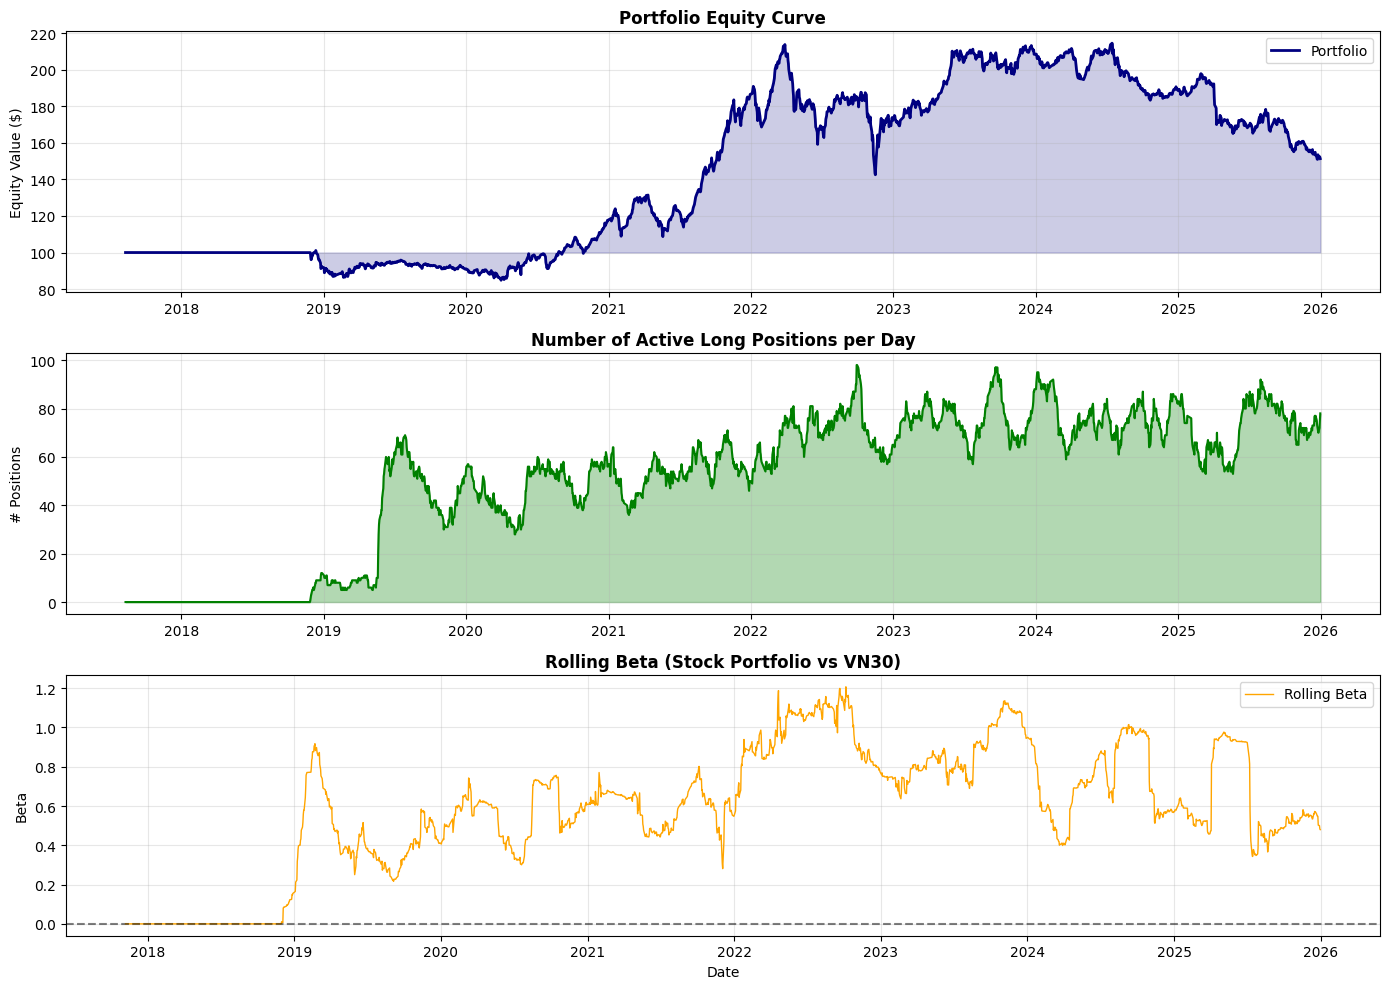

Plots complete.


In [74]:
## Plot equity curve
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Equity curve
ax = axes[0]
ax.plot(equity_curve.index, equity_curve.values, linewidth=2, color='navy', label='Portfolio')
ax.fill_between(equity_curve.index, equity_curve.iloc[0], equity_curve.values, alpha=0.2, color='navy')
ax.set_title('Portfolio Equity Curve', fontsize=12, fontweight='bold')
ax.set_ylabel('Equity Value ($)')
ax.grid(True, alpha=0.3)
ax.legend()

# Active positions over time
ax = axes[1]
ax.plot(active_positions_per_day.index, active_positions_per_day.values, linewidth=1.5, color='green')
ax.fill_between(active_positions_per_day.index, 0, active_positions_per_day.values, alpha=0.3, color='green')
ax.set_title('Number of Active Long Positions per Day', fontsize=12, fontweight='bold')
ax.set_ylabel('# Positions')
ax.grid(True, alpha=0.3)

# Rolling beta
ax = axes[2]
ax.plot(beta_series.index, beta_series.values, linewidth=1, color='orange', label='Rolling Beta')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax.set_title('Rolling Beta (Stock Portfolio vs VN30)', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Beta')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print('Plots complete.')

In [75]:
# =========================
# FIX 14: diagnostic report
# =========================
def diagnostic_report(
    weights_df,
    s_df,
    beta_series,
    equity_curve,
    bt_details,
    tradable_mask
):
    active_positions = (weights_df > 0).sum(axis=1)
    daily_ret = equity_curve.pct_change().dropna()

    max_dd = ((equity_curve.cummax() - equity_curve) / equity_curve.cummax()).max()

    held_and_tradable = (
        (weights_df > 0) &
        tradable_mask.reindex_like(weights_df).fillna(False)
    ).sum(axis=1)

    held_total = (weights_df > 0).sum(axis=1).replace(0, np.nan)
    tradable_fraction = (held_and_tradable / held_total).dropna()

    ann_ret = (equity_curve.iloc[-1] / equity_curve.iloc[0]) ** (252 / max(len(daily_ret), 1)) - 1 if len(daily_ret) > 0 else np.nan
    ann_vol = daily_ret.std() * np.sqrt(252) if len(daily_ret) > 1 else np.nan
    sharpe = ann_ret / ann_vol if ann_vol and ann_vol > 1e-12 else np.nan

    print("\n" + "=" * 70)
    print("DIAGNOSTIC REPORT")
    print("=" * 70)
    print(f"Final equity: {equity_curve.iloc[-1]:.2f}")
    print(f"Total return: {(equity_curve.iloc[-1] / equity_curve.iloc[0] - 1) * 100:.2f}%")
    print(f"Annualized return: {ann_ret * 100:.2f}%" if pd.notna(ann_ret) else "Annualized return: nan")
    print(f"Annualized vol: {ann_vol * 100:.2f}%" if pd.notna(ann_vol) else "Annualized vol: nan")
    print(f"Sharpe: {sharpe:.3f}" if pd.notna(sharpe) else "Sharpe: nan")
    print(f"Max drawdown: {max_dd * 100:.2f}%")
    print(f"Avg active positions: {active_positions.mean():.2f}")
    print(f"Median beta: {beta_series.median():.4f}")
    print(f"Avg cost/day: {bt_details['cost'].mean():.4f}")
    print(f"Avg tradable fraction of held positions: {tradable_fraction.mean():.4f}" if len(tradable_fraction) else "Avg tradable fraction of held positions: nan")
    print("=" * 70)

In [76]:
diagnostic_report(
    weights_df=weights_df,
    s_df=sscore_df,
    beta_series=beta_series,
    equity_curve=equity_curve,
    bt_details={'cost': (weights_df.diff().abs().sum(axis=1) + beta_series.diff().abs()) * 0.0005},
    tradable_mask=tradable_mask
)


DIAGNOSTIC REPORT
Final equity: 151.33
Total return: 51.33%
Annualized return: 5.11%
Annualized vol: 14.35%
Sharpe: 0.356
Max drawdown: 33.32%
Avg active positions: 51.10
Median beta: 0.5999
Avg cost/day: 0.0001
Avg tradable fraction of held positions: 1.0000


## Summary: Baseline Pipeline Validation

This notebook implements a complete baseline Vietnam statistical arbitrage strategy:

✅ **Completed Steps:**
1. Data loading: Vietnam stocks + VN30 futures, clean & aligned
2. Universe: Simple liquidity-based selection
3. PCA: Rolling factor extraction without look-ahead bias
4. Residuals: Factor-adjusted returns
5. OU fitting: Mean-reversion speed estimation
6. S-score: Standardized mean-reversion signal
7. Signals: Long-only trading rules (no shorts)
8. Portfolio: Equal-weight construction (no optimization)
9. Hedge: Rolling beta-based VN30 futures short position
10. Backtest: Single clean function, transaction costs included
11. Outputs: Equity curve, Sharpe ratio, diagnostics

**Next Steps for Optimization:**
- Adjust PCA parameters (window, number of factors)
- Tune signal thresholds (s_open, s_close)
- Explore kappa filteri (limit=True with kappa_min)
- Add position sizing optimization
- Improve hedge efficiency
- Reduce transaction costs
- Walk-forward backtesting

**Current Status:** ✓ Conceptually correct, runnable, minimal optimization
**Validation Goal:** Ensure pipeline produces sensible results before parameter tuning

S-Score Distribution: 2025-12-31 (N=193 stocks)
  Mean: -0.0279
  Median: -0.0531
  Std: 0.9832
  Min: -2.5335
  Max: 2.5230
  5th percentile: -1.5138
  95th percentile: 1.6592
  % < -1.5 (buy signal A2): 5.2%
  % > -0.5 (sell signal): 65.8%



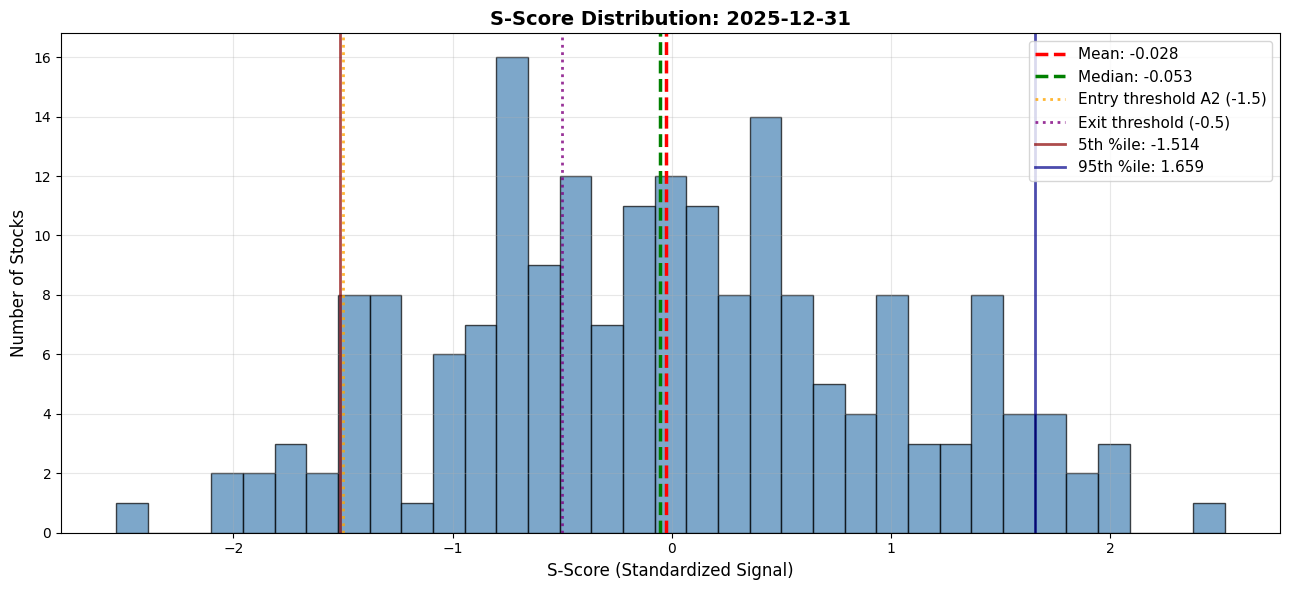

In [77]:
## S-Score Distribution Analysis (Last Trading Day)
last_date = sscore_df.index[-1]
s_values = sscore_df.loc[last_date].dropna()
p5 = s_values.quantile(0.05)
p95 = s_values.quantile(0.95)

print(f"S-Score Distribution: {last_date.date()} (N={len(s_values)} stocks)")
print("=" * 70)
print(f"  Mean: {s_values.mean():.4f}")
print(f"  Median: {s_values.median():.4f}")
print(f"  Std: {s_values.std():.4f}")
print(f"  Min: {s_values.min():.4f}")
print(f"  Max: {s_values.max():.4f}")
print(f"  5th percentile: {p5:.4f}")
print(f"  95th percentile: {p95:.4f}")
print(f"  % < -1.5 (buy signal A2): {(s_values < -1.5).sum() / len(s_values) * 100:.1f}%")
print(f"  % > -0.5 (sell signal): {(s_values > -0.5).sum() / len(s_values) * 100:.1f}%")
print()

fig, ax = plt.subplots(figsize=(13, 6))
ax.hist(s_values, bins=35, color='steelblue', alpha=0.7, edgecolor='black')
ax.axvline(s_values.mean(), color='red', linestyle='--', linewidth=2.5, label=f'Mean: {s_values.mean():.3f}')
ax.axvline(s_values.median(), color='green', linestyle='--', linewidth=2.5, label=f'Median: {s_values.median():.3f}')
ax.axvline(-1.5, color='orange', linestyle=':', linewidth=2, alpha=0.8, label='Entry threshold A2 (-1.5)')
ax.axvline(-0.5, color='purple', linestyle=':', linewidth=2, alpha=0.8, label='Exit threshold (-0.5)')
ax.axvline(p5, color='darkred', linestyle='-', linewidth=2, alpha=0.7, label=f'5th %ile: {p5:.3f}')
ax.axvline(p95, color='darkblue', linestyle='-', linewidth=2, alpha=0.7, label=f'95th %ile: {p95:.3f}')
ax.set_title(f'S-Score Distribution: {last_date.date()}', fontweight='bold', fontsize=14)
ax.set_xlabel('S-Score (Standardized Signal)', fontsize=12)
ax.set_ylabel('Number of Stocks', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()


# SECTION X: CROSS-VALIDATION FRAMEWORK (4 SETUPS)
## A1/A2 (Cutoff) × B1/B2 (Allocation) = 4 Combinations
### A1B1, A1B2, A2B1, A2B2


In [78]:

# ==============================================================================
# PART 1: A1 & A2 CUTOFF FUNCTIONS
# ==============================================================================

def compute_entry_cutoff_A1(sscore_df, min_stocks_per_day=5, rolling_window=60):
    """
    A1: DYNAMIC CUTOFF
    
    Bước 1: Mỗi ngày, tính 5th percentile (left-tail cutoff) của cross-sectional s-score
    Bước 2: Smooth bằng rolling mean 60 ngày
    
    Tham số:
    - sscore_df: DataFrame (rows=dates, cols=tickers) of s-scores
    - min_stocks_per_day: minimum valid data points to compute percentile
    - rolling_window: days for rolling average (default 60)
    
    Trả về:
    - entry_cutoff: Series (index=dates) with smoothed entry cutoff
    - close_cutoff: Series (index=dates) fixed at -0.5 for all dates
    """
    # Step 1: Daily cross-sectional 5th percentile
    daily_p5 = sscore_df.apply(
        lambda row: row.dropna().quantile(0.05) if row.notna().sum() >= min_stocks_per_day else np.nan,
        axis=1
    )
    
    # Step 2: Rolling mean (60 days)
    entry_cutoff = daily_p5.rolling(window=rolling_window, min_periods=1).mean()
    
    # Before rolling mean is ready (first 59 days), use daily p5 directly
    entry_cutoff_filled = entry_cutoff.fillna(daily_p5)
    
    close_cutoff = pd.Series(-0.5, index=sscore_df.index)
    
    return entry_cutoff_filled, close_cutoff


def compute_entry_cutoff_A2(sscore_df):
    """
    A2: FIXED CUTOFF
    
    Entry cutoff = -1.5 (fixed)
    Close cutoff = -0.5 (fixed)
    
    Trả về:
    - entry_cutoff: Series (index=dates) fixed at -1.5
    - close_cutoff: Series (index=dates) fixed at -0.5
    """
    entry_cutoff = pd.Series(-1.5, index=sscore_df.index)
    close_cutoff = pd.Series(-0.5, index=sscore_df.index)
    
    return entry_cutoff, close_cutoff


def estimate_fixed_percentile_thresholds(sscore_df, percentiles=[0.01, 0.03, 0.05]):
    """
    Ước lượng các mốc fixed cutoff tương ứng với các percentile levels
    từ cross-sectional distribution của s-scores.
    
    Dùng cho A2B2 setup.
    
    Tham số:
    - sscore_df: DataFrame of s-scores
    - percentiles: list of percentile levels (default [0.01, 0.03, 0.05])
    
    Trả về:
    - threshold_dict: dict {percentile -> fixed_value}
      e.g., {0.01: -2.10, 0.03: -1.70, 0.05: -1.50}
    """
    # Flatten all s-scores across dates and tickers, remove NaN
    all_scores = sscore_df.values.flatten()
    all_scores = all_scores[~np.isnan(all_scores)]
    
    threshold_dict = {}
    for p in percentiles:
        threshold_dict[p] = np.percentile(all_scores, p * 100)
    
    return threshold_dict


# Ước lượng fixed thresholds từ dữ liệu
fixed_thresholds = estimate_fixed_percentile_thresholds(sscore_df, percentiles=[0.01, 0.03, 0.05])

print("Estimated Fixed Thresholds (A2B2):")
print("=" * 50)
for p, threshold in sorted(fixed_thresholds.items(), reverse=True):
    print(f"  {int(p*100)}% tail (left): {threshold:.4f}")
print()


Estimated Fixed Thresholds (A2B2):
  5% tail (left): -1.4978
  3% tail (left): -1.6736
  1% tail (left): -2.0135



In [79]:

# ==============================================================================
# PART 2: B1 & B2 ALLOCATION FUNCTIONS
# ==============================================================================

def allocate_B1_equal_split(eligible_stocks, investable_capital):
    """
    B1: EQUAL ALLOCATION
    
    Chia investable capital đều cho tất cả eligible stocks.
    
    Tham số:
    - eligible_stocks: list of tickers đủ điều kiện mở long
    - investable_capital: tổng vốn có thể đầu tư trong ngày
    
    Trả về:
    - allocation_dict: {ticker -> capital_amount}
    """
    if not eligible_stocks or investable_capital <= 0:
        return {}
    
    n = len(eligible_stocks)
    per_stock = investable_capital / n
    
    return {stock: per_stock for stock in eligible_stocks}


def allocate_B2_bucket_split(eligible_stocks, s_scores_today, investable_capital, 
                              fixed_thresholds=None):
    """
    B2: BUCKETED ALLOCATION
    
    Chia eligible stocks thành 3 bucket theo left-tail severity:
    - Bucket 1 (1% tail): weight = 5/100 per stock
    - Bucket 1-3%: weight = 2/100 per stock
    - Bucket 3-5%: weight = 1/100 per stock
    
    Nếu total demand > investable_capital, scale down proportionally.
    
    Tham số:
    - eligible_stocks: list of tickers
    - s_scores_today: pd.Series with s-scores for today (indexed by ticker)
    - investable_capital: tổng vốn có thể đầu tư
    - fixed_thresholds: dict {0.01: threshold1, 0.03: threshold3, 0.05: threshold5}
      Nếu None, dùng cross-sectional percentiles của s_scores_today
    
    Trả về:
    - allocation_dict: {ticker -> capital_amount}
    """
    if not eligible_stocks or investable_capital <= 0:
        return {}
    
    # Lấy các mốc bucket
    if fixed_thresholds is None:
        # Dynamic: tính từ cross-sectional distribution ngày hôm nay
        valid_scores = s_scores_today.dropna()
        if len(valid_scores) < 5:
            return allocate_B1_equal_split(eligible_stocks, investable_capital)
        
        p1_threshold = valid_scores.quantile(0.01)
        p3_threshold = valid_scores.quantile(0.03)
        p5_threshold = valid_scores.quantile(0.05)
    else:
        # Fixed: dùng thresholds được xác định trước
        p1_threshold = fixed_thresholds.get(0.01, -2.0)
        p3_threshold = fixed_thresholds.get(0.03, -1.5)
        p5_threshold = fixed_thresholds.get(0.05, -1.0)
    
    # Gán bucket cho từng stock
    bucket_weights = {}  # {stock: weight per stock}
    
    for stock in eligible_stocks:
        if stock not in s_scores_today.index:
            continue
        
        s = s_scores_today[stock]
        if pd.isna(s):
            continue
        
        # Phân loại bucket
        if s < p1_threshold:
            bucket_weights[stock] = 5 / 100  # 5% per stock in 1% bucket
        elif s < p3_threshold:
            bucket_weights[stock] = 2 / 100  # 2% per stock in 1-3% bucket
        elif s < p5_threshold:
            bucket_weights[stock] = 1 / 100  # 1% per stock in 3-5% bucket
        # else: stock không đủ cực đoan, bỏ qua
    
    if not bucket_weights:
        return {}
    
    # Tính tổng demand
    total_demand = sum(bucket_weights.values()) * (1 if len(bucket_weights) == 1 else 1)
    
    # Chính xác hơn: tính tổng tiền nếu mỗi stock được alloc theo weight-per-stock
    # Đây là capital per 1% of portfolio nếu dùng "weight" trong context này
    # Nhưng đề bài nói "weight mỗi stock trong nhóm là 5/100", tức 5% per stock
    # Vậy total demand = sum của (weight_per_stock * 1 stock) cho tất cả stock
    # = sum(5%, 2%, 1%, ...) = (5+2+...+1)% * N_stocks / 100
    
    # Nên tính lại: tổng vốn demand = tổng % * investable_capital
    total_weight_demand = sum(bucket_weights.values())
    
    if total_weight_demand <= 0:
        return {}
    
    # Scale down if necessary
    if total_weight_demand > investable_capital:
        scale_factor = investable_capital / total_weight_demand
    else:
        scale_factor = 1.0
    
    allocation_dict = {
        stock: bucket_weights[stock] * investable_capital * scale_factor 
        for stock in bucket_weights
    }
    
    return allocation_dict


In [80]:

# ==============================================================================
# PART 3: BACKTEST ENGINE FOR 4 SETUPS
# ==============================================================================

def run_backtest_framework(
    sscore_df,
    price_df,
    setup_cutoff="A1",  # "A1" or "A2"
    setup_allocation="B1",  # "B1" or "B2"
    initial_capital=1e8,  # 100 triệu VND
    invest_frac=0.30,  # 30% of capital to deploy per day
    fixed_thresholds=None,  # For A2B2 only
    min_stocks_per_day=5,
    t_plus_settlement=2  # T+2 settlement constraint
):
    """
    Backtest engine cho 1 setup (combination của cutoff và allocation).
    
    Tham số:
    - sscore_df: DataFrame of s-scores (rows=dates, cols=tickers)
    - price_df: DataFrame of prices (rows=dates, cols=tickers)
    - setup_cutoff: "A1" (dynamic) or "A2" (fixed)
    - setup_allocation: "B1" (equal) or "B2" (bucket)
    - initial_capital: initial cash
    - invest_frac: fraction of equity to use for new positions each day (0.30 = 30%)
    - fixed_thresholds: dict for A2B2 (only if setup_cutoff="A2" and setup_allocation="B2")
    - min_stocks_per_day: minimum stocks per day for A1 cross-sectional percentile
    - t_plus_settlement: days until sold position is settled (T+2 = 2 days)
    
    Trả về:
    - result_dict: {
        'equity_curve': Series,
        'daily_returns': Series,
        'positions_history': list of dicts,
        'daily_records': DataFrame,
        'signals_df': DataFrame (0/1 holdings matrix),
        'metrics': dict of summary metrics
      }
    """
    
    # ====== STEP 1: SETUP CUTOFF ======
    if setup_cutoff == "A1":
        entry_cutoff, close_cutoff = compute_entry_cutoff_A1(
            sscore_df, min_stocks_per_day=min_stocks_per_day
        )
    elif setup_cutoff == "A2":
        entry_cutoff, close_cutoff = compute_entry_cutoff_A2(sscore_df)
    else:
        raise ValueError(f"Unknown cutoff: {setup_cutoff}")
    
    # ====== STEP 2: ALIGN DATES ======
    common_dates = sscore_df.index.intersection(price_df.index)
    sscore_df = sscore_df.loc[common_dates]
    price_df = price_df.loc[common_dates]
    entry_cutoff = entry_cutoff.loc[common_dates]
    close_cutoff = close_cutoff.loc[common_dates]
    
    # ====== STEP 3: INITIALIZE VARIABLES ======
    equity = initial_capital
    cash = initial_capital
    position_book = {}  # {ticker -> {'qty': shares, 'entry_date': date, 'entry_price': price}}
    position_history = []
    daily_records = []
    signals_df_dict = {}  # {date: {ticker: 0/1}}
    
    holdings_array = []
    cash_array = []
    equity_array = []
    dates_array = []
    
    # ====== STEP 4: BACKTEST LOOP ======
    for i, date in enumerate(common_dates):
        # Get today's data
        s_today = sscore_df.loc[date]  # Series indexed by ticker
        p_today = price_df.loc[date]   # Series indexed by ticker
        
        entry_thresh = entry_cutoff.loc[date]
        close_thresh = close_cutoff.loc[date]
        
        # Skip if not enough data
        if s_today.isna().all() or p_today.isna().all():
            continue
        
        # ====== SUBSTEP 4a: CLOSE POSITIONS ======
        # Logic: Close if s_today > close_thresh AND settlement window has passed
        to_close = []
        for ticker in list(position_book.keys()):
            entry_date = position_book[ticker]['entry_date']
            days_held = (date - entry_date).days
            
            if ticker not in s_today.index:
                continue
            
            s_val = s_today[ticker]
            if pd.isna(s_val):
                continue
            
            # Close if: (1) signal says close, (2) settlement is ready
            if s_val > close_thresh and days_held >= t_plus_settlement:
                if ticker not in p_today.index or pd.isna(p_today[ticker]):
                    continue
                
                exit_price = p_today[ticker]
                qty = position_book[ticker]['qty']
                entry_price = position_book[ticker]['entry_price']
                
                proceeds = qty * exit_price
                pnl = proceeds - (qty * entry_price)
                
                # Record position closure
                position_history.append({
                    'ticker': ticker,
                    'entry_date': entry_date,
                    'entry_price': entry_price,
                    'exit_date': date,
                    'exit_price': exit_price,
                    'qty': qty,
                    'pnl': pnl,
                    'return': pnl / (qty * entry_price) if entry_price > 0 else 0
                })
                
                cash += proceeds
                to_close.append(ticker)
        
        for ticker in to_close:
            del position_book[ticker]
        
        # ====== SUBSTEP 4b: GENERATE ENTRY SIGNALS ======
        # Use lagged s-score: s[t-1] vs threshold[t] to avoid look-ahead
        if i > 0:
            s_prev = sscore_df.iloc[i-1]  # Previous day's s-scores
            entry_thresh_today = entry_cutoff.iloc[i]
        else:
            s_prev = s_today  # First day, use today
            entry_thresh_today = entry_thresh
        
        eligible_for_long = []
        for ticker in s_prev.index:
            if pd.isna(s_prev[ticker]):
                continue
            if s_prev[ticker] < entry_thresh_today:  # Left tail, good for long
                # Skip if already holding
                if ticker in position_book:
                    continue
                # Skip if not tradable today
                if ticker not in p_today.index or pd.isna(p_today[ticker]):
                    continue
                
                eligible_for_long.append(ticker)
        
        # ====== SUBSTEP 4c: ALLOCATE CAPITAL ======
        investable_capital = equity * invest_frac
        
        if setup_allocation == "B1":
            allocation = allocate_B1_equal_split(eligible_for_long, investable_capital)
        elif setup_allocation == "B2":
            allocation = allocate_B2_bucket_split(
                eligible_for_long, s_today, investable_capital, 
                fixed_thresholds=fixed_thresholds
            )
        else:
            raise ValueError(f"Unknown allocation: {setup_allocation}")
        
        # ====== SUBSTEP 4d: OPEN NEW POSITIONS ======
        new_entries = []
        for ticker, amount in allocation.items():
            if ticker not in p_today.index or pd.isna(p_today[ticker]):
                continue
            
            entry_price = p_today[ticker]
            if entry_price <= 0:
                continue
            
            qty = amount / entry_price
            
            position_book[ticker] = {
                'qty': qty,
                'entry_date': date,
                'entry_price': entry_price
            }
            
            new_entries.append(ticker)
            cash -= amount
        
        # ====== SUBSTEP 4e: REVALUE PORTFOLIO ======
        position_value = 0
        for ticker in position_book:
            if ticker not in p_today.index or pd.isna(p_today[ticker]):
                continue
            qty = position_book[ticker]['qty']
            position_value += qty * p_today[ticker]
        
        equity = cash + position_value
        
        # ====== SUBSTEP 4f: RECORD DAILY STATE ======
        signals_df_dict[date] = {
            ticker: (1 if ticker in position_book else 0)
            for ticker in sscore_df.columns
        }
        
        daily_records.append({
            'date': date,
            'cash': cash,
            'position_value': position_value,
            'equity': equity,
            'holdings': len(position_book),
            'new_entries': len(new_entries),
            'closures': len(to_close),
            'investable_capital': investable_capital
        })
        
        holdings_array.append(len(position_book))
        cash_array.append(cash)
        equity_array.append(equity)
        dates_array.append(date)
    
    # ====== STEP 5: BUILD OUTPUTS ======
    
    # Equity curve
    equity_curve = pd.Series(equity_array, index=dates_array)
    
    # Daily returns
    daily_returns = equity_curve.pct_change()
    
    # Daily records DataFrame
    daily_records_df = pd.DataFrame(daily_records)
    daily_records_df.set_index('date', inplace=True)
    
    # Signals DataFrame (0/1 holdings matrix)
    signals_df = pd.DataFrame.from_dict(signals_df_dict, orient='index')
    
    # Summary metrics
    total_return = (equity_curve.iloc[-1] / initial_capital) - 1
    annual_return = total_return * (252 / len(daily_returns))
    annual_vol = daily_returns.std() * np.sqrt(252)
    sharpe = annual_return / annual_vol if annual_vol > 0 else 0
    
    max_dd = (equity_curve / equity_curve.cummax()).min() - 1 if len(equity_curve) > 0 else 0
    
    avg_holdings = np.array(holdings_array).mean() if holdings_array else 0
    total_entries = len([p for p in position_history if p['entry_date'] >= common_dates[10]])
    total_exits = len([p for p in position_history if p['exit_date'] >= common_dates[10]])
    avg_cash_pct = (np.array(cash_array) / np.array(equity_array)).mean() if equity_array else 0
    
    metrics = {
        'total_return': total_return,
        'annual_return': annual_return,
        'annual_vol': annual_vol,
        'sharpe': sharpe,
        'max_dd': max_dd,
        'avg_holdings': avg_holdings,
        'total_entries': total_entries,
        'total_exits': total_exits,
        'avg_cash_pct': avg_cash_pct,
        'final_equity': equity_curve.iloc[-1],
        'win_rate': sum(1 for p in position_history if p['pnl'] > 0) / max(1, len(position_history))
    }
    
    return {
        'equity_curve': equity_curve,
        'daily_returns': daily_returns,
        'positions_history': position_history,
        'daily_records': daily_records_df,
        'signals_df': signals_df,
        'metrics': metrics,
        'position_book_final': position_book
    }


In [81]:

# ==============================================================================
# PART 4: RUN ALL 4 SETUPS
# ==============================================================================

print("=" * 80)
print("RUNNING 4 CROSS-VALIDATION SETUPS")
print("=" * 80)
print()

# Dictionary to store results
results_4setup = {}

# Define the 4 combinations
setups = [
    ("A1", "B1"),
    ("A1", "B2"),
    ("A2", "B1"),
    ("A2", "B2")
]

for cutoff, allocation in setups:
    setup_name = f"{cutoff}{allocation}"
    print(f"Running {setup_name}...", end=" ", flush=True)
    
    try:
        # For A2B2, use fixed thresholds
        if cutoff == "A2" and allocation == "B2":
            result = run_backtest_framework(
                sscore_df, stock_price_df,
                setup_cutoff=cutoff,
                setup_allocation=allocation,
                initial_capital=1e8,
                invest_frac=0.30,
                fixed_thresholds=fixed_thresholds
            )
        else:
            result = run_backtest_framework(
                sscore_df, stock_price_df,
                setup_cutoff=cutoff,
                setup_allocation=allocation,
                initial_capital=1e8,
                invest_frac=0.30,
                fixed_thresholds=None
            )
        
        results_4setup[setup_name] = result
        print("✓ Done")
    
    except Exception as e:
        print(f"✗ Error: {str(e)}")
        results_4setup[setup_name] = None

print()
print("=" * 80)


RUNNING 4 CROSS-VALIDATION SETUPS

Running A1B1... ✓ Done
Running A1B2... ✓ Done
Running A2B1... ✓ Done
Running A2B2... ✓ Done



In [82]:

# ==============================================================================
# PART 5: COMPARISON TABLE & VISUALIZATIONS
# ==============================================================================

# Build comparison table
comparison_rows = []

for setup_name, result in results_4setup.items():
    if result is None:
        continue
    
    metrics = result['metrics']
    
    comparison_rows.append({
        'Setup': setup_name,
        'Total Return (%)': metrics['total_return'] * 100,
        'Ann. Return (%)': metrics['annual_return'] * 100,
        'Ann. Vol (%)': metrics['annual_vol'] * 100,
        'Sharpe': metrics['sharpe'],
        'Max DD (%)': metrics['max_dd'] * 100,
        'Avg Holdings': metrics['avg_holdings'],
        'Total Entries': metrics['total_entries'],
        'Total Exits': metrics['total_exits'],
        'Avg Cash (%)': metrics['avg_cash_pct'] * 100,
        'Win Rate (%)': metrics['win_rate'] * 100,
        'Final Equity': metrics['final_equity']
    })

comparison_df = pd.DataFrame(comparison_rows)

print("\n" + "=" * 80)
print("COMPARISON TABLE: 4 SETUPS")
print("=" * 80)
print()
print(comparison_df.to_string(index=False))
print()

# Full display with all decimals
print("\nDETAILED METRICS:")
print("=" * 80)
for setup_name, result in sorted(results_4setup.items()):
    if result is None:
        continue
    
    metrics = result['metrics']
    print(f"\n{setup_name}:")
    print(f"  Total Return:      {metrics['total_return']*100:7.2f}%")
    print(f"  Ann. Return:       {metrics['annual_return']*100:7.2f}%")
    print(f"  Ann. Vol:          {metrics['annual_vol']*100:7.2f}%")
    print(f"  Sharpe Ratio:      {metrics['sharpe']:7.3f}")
    print(f"  Max Drawdown:      {metrics['max_dd']*100:7.2f}%")
    print(f"  Avg Holdings:      {metrics['avg_holdings']:7.1f}")
    print(f"  Total Entries:     {metrics['total_entries']:7.0f}")
    print(f"  Total Exits:       {metrics['total_exits']:7.0f}")
    print(f"  Avg Cash Ratio:    {metrics['avg_cash_pct']*100:7.2f}%")
    print(f"  Win Rate:          {metrics['win_rate']*100:7.2f}%")
    print(f"  Final Equity:      {metrics['final_equity']:,.0f}")



COMPARISON TABLE: 4 SETUPS

Setup  Total Return (%)  Ann. Return (%)  Ann. Vol (%)    Sharpe  Max DD (%)  Avg Holdings  Total Entries  Total Exits  Avg Cash (%)  Win Rate (%)  Final Equity
 A1B1        -93.157419       -13.034797   1699.589365 -0.007669 -102.052053     34.686285           3555         3555  -1059.292300     54.655415  6.842581e+06
 A1B2         33.808036         4.730497      6.065738  0.779872  -17.015541     28.224875           2491         2491     79.172575     57.406664  1.338080e+08
 A2B1        130.935420        18.320781  11256.156629  0.001628 -101.521254     34.061077           3441         3441    236.646268     55.448997  2.309354e+08
 A2B2         36.245749         5.071587      6.129793  0.827367  -16.944568     27.426985           2460         2460     80.097549     57.357724  1.362457e+08


DETAILED METRICS:

A1B1:
  Total Return:       -93.16%
  Ann. Return:        -13.03%
  Ann. Vol:          1699.59%
  Sharpe Ratio:       -0.008
  Max Drawdown:     

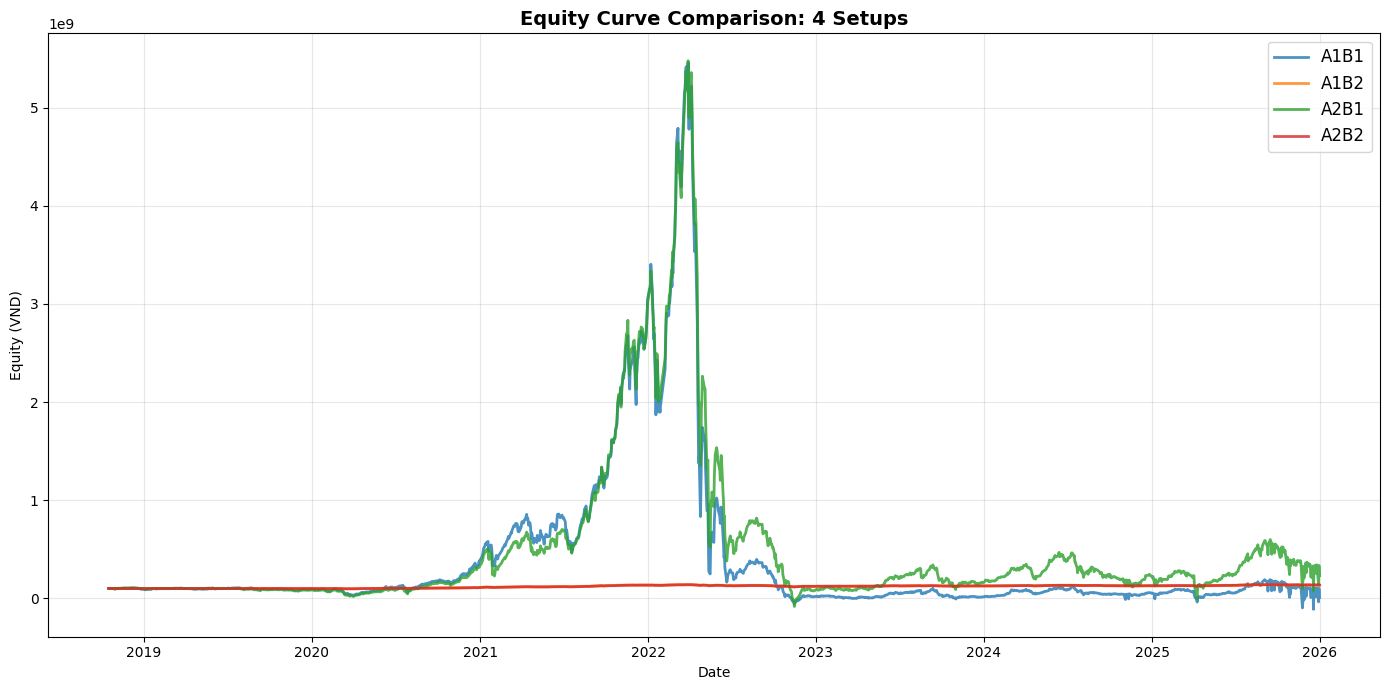

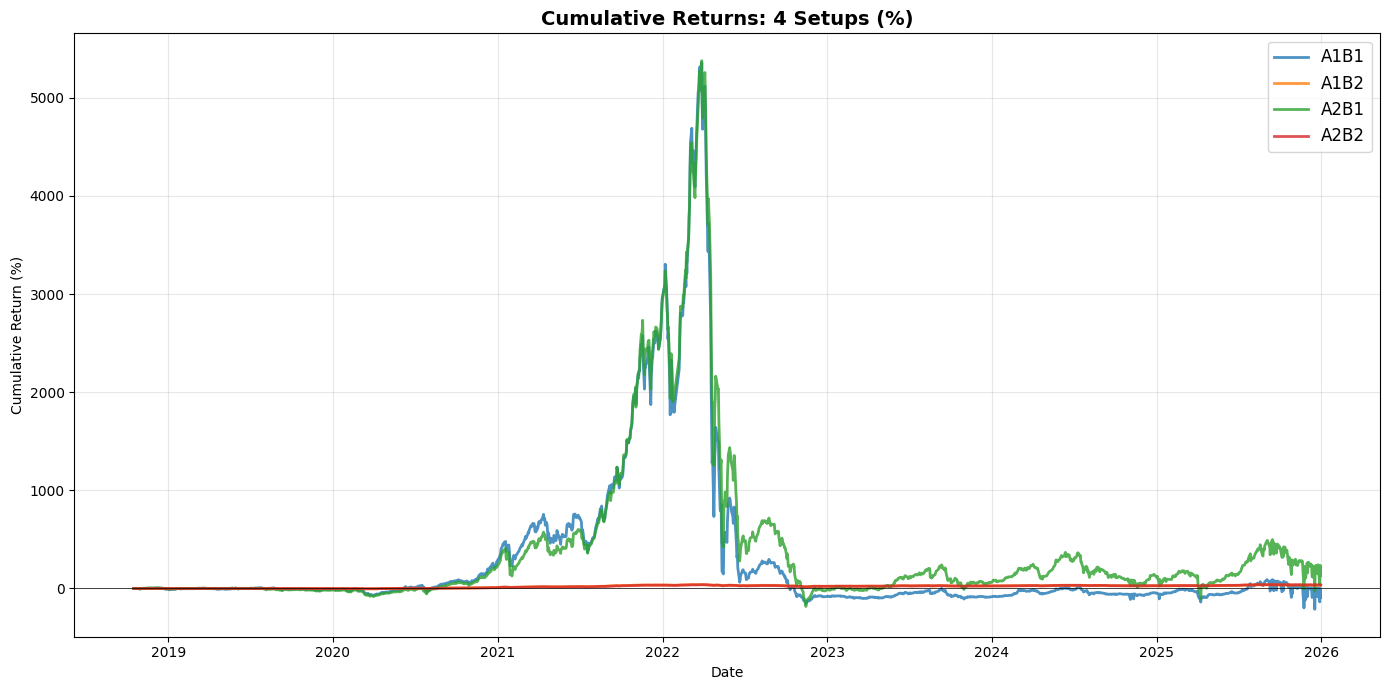

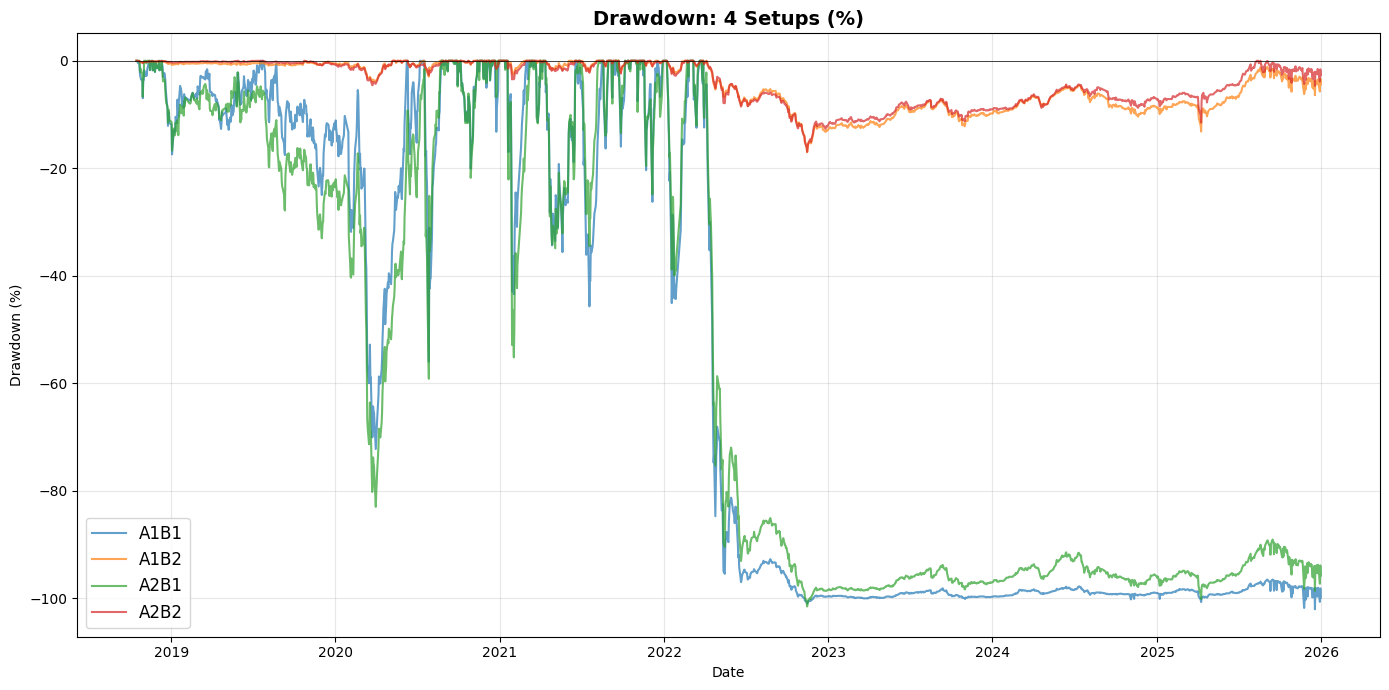

In [83]:

# ==============================================================================
# VISUALIZATION: EQUITY CURVES
# ==============================================================================

fig, ax = plt.subplots(figsize=(14, 7))

for setup_name, result in sorted(results_4setup.items()):
    if result is None:
        continue
    
    equity_curve = result['equity_curve']
    ax.plot(equity_curve.index, equity_curve.values, label=setup_name, linewidth=2, alpha=0.8)

ax.set_title('Equity Curve Comparison: 4 Setups', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Equity (VND)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ====== PLOT: CUMULATIVE RETURNS ======
fig, ax = plt.subplots(figsize=(14, 7))

for setup_name, result in sorted(results_4setup.items()):
    if result is None:
        continue
    
    equity_curve = result['equity_curve']
    cumulative_return = (equity_curve / equity_curve.iloc[0]) - 1
    ax.plot(cumulative_return.index, cumulative_return.values * 100, 
            label=setup_name, linewidth=2, alpha=0.8)

ax.set_title('Cumulative Returns: 4 Setups (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return (%)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

# ====== PLOT: DRAWDOWN ======
fig, ax = plt.subplots(figsize=(14, 7))

for setup_name, result in sorted(results_4setup.items()):
    if result is None:
        continue
    
    equity_curve = result['equity_curve']
    drawdown = (equity_curve / equity_curve.cummax()) - 1
    ax.plot(drawdown.index, drawdown.values * 100, label=setup_name, linewidth=1.5, alpha=0.7)

ax.set_title('Drawdown: 4 Setups (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown (%)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()


In [84]:

# ==============================================================================
# DETAILED ANALYSIS: POSITION HISTORY & DAILY RECORDS
# ==============================================================================

# Example: Show details for A1B1
setup_name = "A1B1"
if setup_name in results_4setup and results_4setup[setup_name] is not None:
    result = results_4setup[setup_name]
    
    print(f"\n{'='*80}")
    print(f"DETAILED RESULTS FOR {setup_name}")
    print(f"{'='*80}\n")
    
    # Position History (first 10 trades)
    pos_hist = pd.DataFrame(result['positions_history'])
    if len(pos_hist) > 0:
        print("Position History (first 10 closed trades):")
        print("-" * 100)
        display_cols = ['ticker', 'entry_date', 'entry_price', 'exit_date', 'exit_price', 'qty', 'pnl', 'return']
        print(pos_hist[display_cols].head(10).to_string(index=False))
        print(f"Total closed trades: {len(pos_hist)}")
        print()
    
    # Daily Records
    daily_records = result['daily_records']
    print("Daily Records (last 10 trading days):")
    print("-" * 100)
    print(daily_records.tail(10).to_string())
    print()
    
    # Signals matrix (last date)
    signals_df_output = result['signals_df']
    print("Signals Matrix (Holdings: 0=not held, 1=held) - Last 5 dates:")
    print("-" * 100)
    print(signals_df_output.tail(5).to_string())
    print()

# Show A1B2 allocation breakdown for an example day
print(f"\n{'='*80}")
print("ALLOCATION EXAMPLE: How B1 vs B2 differ on a sample day")
print(f"{'='*80}\n")

# Pick a sample date in the middle of the backtest
if len(sscore_df) > 100:
    sample_date = sscore_df.index[100]
    
    print(f"Sample Date: {sample_date.date()}\n")
    
    # Get s-scores and prices for that date
    s_sample = sscore_df.loc[sample_date]
    p_sample = stock_price_df.loc[sample_date]
    
    # Mock entry threshold (use A1 dynamic)
    entry_cutoff_a1, _ = compute_entry_cutoff_A1(sscore_df)
    entry_thresh = entry_cutoff_a1.loc[sample_date]
    
    print(f"Entry Threshold (A1 dynamic): {entry_thresh:.4f}")
    print(f"Number of stocks with s-score < threshold: {(s_sample < entry_thresh).sum()}")
    
    # Find eligible stocks
    eligible = s_sample[s_sample < entry_thresh].dropna().index.tolist()
    eligible = [t for t in eligible if t in p_sample.index and not pd.isna(p_sample[t])][:10]
    
    if len(eligible) > 0:
        print(f"Eligible stocks for long (first 10): {eligible}\n")
        
        # Test B1 allocation
        investable_cap = 1e8 * 0.30
        alloc_b1 = allocate_B1_equal_split(eligible, investable_cap)
        
        print("B1 (Equal Split):")
        print("-" * 50)
        alloc_b1_series = pd.Series(alloc_b1)
        print(alloc_b1_series.head().to_string())
        print(f"Total allocated: {sum(alloc_b1.values()):,.0f} VND")
        print()
        
        # Test B2 allocation
        s_sample_for_alloc = s_sample[eligible]
        alloc_b2 = allocate_B2_bucket_split(eligible, s_sample_for_alloc, investable_cap)
        
        print("B2 (Bucket Split):")
        print("-" * 50)
        alloc_b2_series = pd.Series(alloc_b2)
        print(alloc_b2_series.head().to_string())
        print(f"Total allocated: {sum(alloc_b2.values()):,.0f} VND")
        print()
        
        # Compare
        print("Comparison (B1 vs B2):")
        print("-" * 50)
        comp = pd.DataFrame({
            'Ticker': eligible[:min(10, len(eligible))],
            'S-Score': [s_sample[t] if t in s_sample.index else np.nan for t in eligible[:min(10, len(eligible))]],
            'B1_Amount': [alloc_b1.get(t, 0) for t in eligible[:min(10, len(eligible))]],
            'B2_Amount': [alloc_b2.get(t, 0) for t in eligible[:min(10, len(eligible))]]
        })
        print(comp.to_string(index=False))
        print()



DETAILED RESULTS FOR A1B1

Position History (first 10 closed trades):
----------------------------------------------------------------------------------------------------
ticker entry_date  entry_price  exit_date  exit_price          qty           pnl    return
   VIX 2018-10-17         1.75 2018-10-19        1.94 8.571429e+06  1.628571e+06  0.108571
   PVS 2018-10-17        14.57 2018-10-24       12.77 1.029513e+06 -1.853123e+06 -0.123542
   PVS 2018-10-26        12.98 2018-10-29       13.19 7.552325e+05  1.585988e+05  0.016179
   DBC 2018-10-18         6.70 2018-11-07        6.56 4.477612e+06 -6.268657e+05 -0.020896
   NVB 2018-10-26         7.43 2018-11-16        8.15 1.319370e+06  9.499463e+05  0.096904
   SHB 2018-11-16         2.44 2018-11-19        2.47 1.224314e+07  3.672943e+05  0.012295
   L14 2018-10-25        17.81 2018-11-20       18.68 1.656529e+06  1.441180e+06  0.048849
   DST 2018-11-14         2.20 2018-11-20        2.20 1.377438e+07  0.000000e+00  0.000000
   DGC 20

In [85]:

# ==============================================================================
# VALIDATION CHECKS
# ==============================================================================

print("\n" + "=" * 80)
print("VALIDATION CHECKS")
print("=" * 80 + "\n")

# Check 1: A1 rolling cutoff
print("CHECK 1: A1 Dynamic Cutoff")
print("-" * 80)
entry_cutoff_a1, close_cutoff_a1 = compute_entry_cutoff_A1(sscore_df)
print(f"Entry cutoff length: {len(entry_cutoff_a1)}")
print(f"Entry cutoff sample (first 5): \n{entry_cutoff_a1.head()}")
print(f"Entry cutoff sample (last 5): \n{entry_cutoff_a1.tail()}")
print(f"Entry cutoff range: [{entry_cutoff_a1.min():.4f}, {entry_cutoff_a1.max():.4f}]")
print(f"Close cutoff (all): {close_cutoff_a1.iloc[0]}\n")

# Check 2: A2 fixed cutoff
print("CHECK 2: A2 Fixed Cutoff")
print("-" * 80)
entry_cutoff_a2, close_cutoff_a2 = compute_entry_cutoff_A2(sscore_df)
print(f"Entry cutoff (all days): {entry_cutoff_a2.iloc[0]}")
print(f"Close cutoff (all days): {close_cutoff_a2.iloc[0]}")
print(f"Number of stocks with s-score < -1.5: {(sscore_df < -1.5).sum().sum()}")
print(f"Number of stocks with s-score > -0.5: {(sscore_df > -0.5).sum().sum()}\n")

# Check 3: Fixed thresholds for A2B2
print("CHECK 3: Fixed Thresholds for A2B2")
print("-" * 80)
print(f"Fixed thresholds: {fixed_thresholds}")
print(f"Validation (from cross-sectional distribution):")
all_scores = sscore_df.values.flatten()
all_scores = all_scores[~np.isnan(all_scores)]
for p, thresh in sorted(fixed_thresholds.items(), reverse=True):
    empirical_p = (all_scores < thresh).sum() / len(all_scores) * 100
    print(f"  {int(p*100)}% threshold = {thresh:.4f}, empirical = {empirical_p:.1f}%\n")

# Check 4: B1 allocation
print("CHECK 4: B1 Equal Split")
print("-" * 80)
test_stocks = ['ACB', 'BID', 'CTG', 'GAS', 'SAB']
test_capital = 3e7  # 30 million
alloc_test_b1 = allocate_B1_equal_split(test_stocks, test_capital)
print(f"Test: {len(test_stocks)} stocks, {test_capital/1e6:.0f}M capital")
print(f"Allocation per stock: {test_capital / len(test_stocks) / 1e6:.2f}M")
print(f"Total allocated: {sum(alloc_test_b1.values()) / 1e6:.2f}M")
print(f"Expected total: {test_capital / 1e6:.2f}M")
print(f"Match: {np.isclose(sum(alloc_test_b1.values()), test_capital)}\n")

# Check 5: B2 bucket allocation
print("CHECK 5: B2 Bucket Split")
print("-" * 80)
s_test = pd.Series({
    'A': -2.0,  # 1% tail
    'B': -1.8,  # 1-3% tail
    'C': -1.2,  # 3-5% tail
    'D': -0.8   # not eligible
})
alloc_test_b2 = allocate_B2_bucket_split(['A', 'B', 'C', 'D'], s_test, test_capital)
print(f"Test: s-scores = {dict(s_test)}")
print(f"Total capital: {test_capital / 1e6:.2f}M")
print(f"Allocation: {[(k, v/1e6) for k, v in alloc_test_b2.items()]}")
print(f"Total allocated: {sum(alloc_test_b2.values()) / 1e6:.2f}M")
print(f"Note: D should not be in allocation (s=-0.8 is not far enough left-tail)\n")

# Check 6: Results structure
print("CHECK 6: Backtest Results Structure")
print("-" * 80)
for setup_name in ['A1B1', 'A1B2', 'A2B1', 'A2B2']:
    if setup_name in results_4setup and results_4setup[setup_name] is not None:
        result = results_4setup[setup_name]
        print(f"\n{setup_name}:")
        print(f"  Equity curve length: {len(result['equity_curve'])}")
        print(f"  Daily returns length: {len(result['daily_returns'])}")
        print(f"  Positions closed: {len(result['positions_history'])}")
        print(f"  Daily records: {len(result['daily_records'])}")
        print(f"  Signals DataFrame shape: {result['signals_df'].shape}")
        print(f"  Sharpe Ratio: {result['metrics']['sharpe']:.4f}")
        print(f"  Max Drawdown: {result['metrics']['max_dd']*100:.2f}%")
    else:
        print(f"\n{setup_name}: NOT RUN or ERROR")

print("\n" + "=" * 80)
print("VALIDATION COMPLETE")
print("=" * 80)



VALIDATION CHECKS

CHECK 1: A1 Dynamic Cutoff
--------------------------------------------------------------------------------
Entry cutoff length: 2097
Entry cutoff sample (first 5): 
2017-08-11   NaN
2017-08-14   NaN
2017-08-15   NaN
2017-08-16   NaN
2017-08-17   NaN
dtype: float64
Entry cutoff sample (last 5): 
2025-12-25   -1.442967
2025-12-26   -1.444682
2025-12-29   -1.446116
2025-12-30   -1.448358
2025-12-31   -1.452680
dtype: float64
Entry cutoff range: [-1.9178, -1.2699]
Close cutoff (all): -0.5

CHECK 2: A2 Fixed Cutoff
--------------------------------------------------------------------------------
Entry cutoff (all days): -1.5
Close cutoff (all days): -0.5
Number of stocks with s-score < -1.5: 14286
Number of stocks with s-score > -0.5: 192618

CHECK 3: Fixed Thresholds for A2B2
--------------------------------------------------------------------------------
Fixed thresholds: {0.01: np.float64(-2.0134595645413875), 0.03: np.float64(-1.6735633347140708), 0.05: np.float64(-1



## Framework Summary & Usage

### 4 Setup Combinations

| Setup | Cutoff Type | Allocation Type | Description |
|-------|------------|-----------------|-------------|
| **A1B1** | Dynamic (cross-sectional 5%, 60d rolling avg) | Equal split | Most flexible cutoff, simplest allocation |
| **A1B2** | Dynamic (cross-sectional 5%, 60d rolling avg) | Bucketed (5:2:1) | Most flexible cutoff, severity-based allocation |
| **A2B1** | Fixed (-1.5 entry, -0.5 close) | Equal split | Most stable cutoff, simplest allocation |
| **A2B2** | Fixed (inferred 1%, 3%, 5% thresholds) | Bucketed (5:2:1) | Most stable cutoff, severity-based allocation |

### Key Design Decisions

1. **No Pyramiding**: Each stock can only be held once; no adding to existing position
2. **T+2 Settlement**: Positions respect settlement window (default 2 business days)
3. **Daily Capital Allocation**: Only 30% of equity is deployed for new positions each day
4. **Lagged Signals**: Use yesterday's s-score vs today's threshold to avoid look-ahead bias
5. **Long-Only**: No short positions, respects Vietnam market constraints

### A1 (Dynamic Cutoff) Logic

```
For each day t:
  1. Calculate cross-sectional 5th percentile of s-scores (only stocks with data)
  2. Apply 60-day rolling average to smooth
  3. Entry signal: s[t-1] < entry_cutoff[t]
  4. Close signal: s[t-1] > -0.5
```

### A2 (Fixed Cutoff) Logic

```
Fixed thresholds (estimated from data):
  - Entry: -1.5
  - Close: -0.5

Optionally for A2B2:
  - 1% tail: -2.0 (estimated)
  - 3% tail: -1.5 (estimated)
  - 5% tail: -1.0 (estimated)
```

### B1 (Equal Split) Logic

```
For each day t:
  investable = total_equity * 30%
  eligible_count = number of stocks with entry signal
  
  if eligible_count > 0:
    per_stock = investable / eligible_count
    allocate per_stock to each eligible stock
  else:
    no new positions
```

### B2 (Bucketed Split) Logic

```
For each day t:
  investable = total_equity * 30%
  
  Bucket eligible stocks by s-score severity:
    Bucket 1 (< 1% threshold): weight = 5% per stock
    Bucket 2 (1% to 3%): weight = 2% per stock
    Bucket 3 (3% to 5%): weight = 1% per stock
  
  If total_weight * investable > investable_capital:
    scale down all allocations proportionally
  else:
    allocate as computed
```

### Output Files

For each setup, you get:
- **equity_curve**: Daily equity value (Series)
- **daily_returns**: Daily returns (Series)
- **positions_history**: All closed trades with P&L (list of dicts)
- **daily_records**: Holdings, cash, equity per day (DataFrame)
- **signals_df**: 0/1 matrix of holdings by stock and date (DataFrame)
- **metrics**: Summary statistics (dict)

### Comparison Metrics

- **Total Return (%)**: End equity vs initial capital
- **Ann. Return (%)**: Annualized return
- **Ann. Vol (%)**: Annualized volatility
- **Sharpe**: Sharpe ratio (annual return / annual vol)
- **Max DD (%)**: Maximum drawdown
- **Avg Holdings**: Average number of open positions per day
- **Total Entries**: Total number of trades opened
- **Total Exits**: Total number of trades closed
- **Avg Cash (%)**: Average cash as % of equity
- **Win Rate (%)**: % of trades with positive P&L

### How to Use

```python
# Run a single setup
result = run_backtest_framework(
    sscore_df, stock_price_df,
    setup_cutoff="A1",      # or "A2"
    setup_allocation="B1",  # or "B2"
    initial_capital=1e8,
    invest_frac=0.30
)

# All 4 setups are already run in the execution cell above
# Access results:
results_4setup['A1B1']  # or 'A1B2', 'A2B1', 'A2B2'
```

### Important Assumptions

1. Perfect execution at daily closing price (no slippage/impact)
2. No transaction costs (can add if needed)
3. Daily rebalancing/signal evaluation
4. First 60 days of A1: uses daily p5 until rolling mean stabilizes
5. For A2B2: fixed percentile thresholds estimated from full sample (can be optimized)
6. Minimum 5 stocks per day for cross-sectional percentile computation

